### Ce-bigFISH: image analysis toolkit for *C. elegans* embryo

#### Input image info:

In [1]:
# # # Parameters if running with sbatch script
import os

# # # Retrieve parameters from environment variables
# folder_name = os.getenv('FOLDER_NAME')
# output_directory = os.getenv('OUTPUT_DIRECTORY')

# # Channels
# Cy5 = os.getenv('Cy5')
# mCherry = os.getenv('mCherry')
# FITC = os.getenv('FITC')
# DAPI = os.getenv('DAPI')
# brightfield = os.getenv('brightfield')

# # Microscope parameters
# wavelength_cy5 = int(os.getenv('wavelength_cy5', 670))
# wavelength_mCherry = int(os.getenv('wavelength_mCherry', 610))
# na = float(os.getenv('na', 1.42))
# refractive_index_medium = float(os.getenv('refractive_index_medium', 1.515))

# # PSF parameters
# psf_calculator = os.getenv('PSF_CALCULATOR', 'False') == 'False'
# spot_radius_ch0 = tuple(map(int, os.getenv('SPOT_RADIUS_CH0', '1409,340,340').split(',')))
# spot_radius_ch1 = tuple(map(int, os.getenv('SPOT_RADIUS_CH1', '1283,310,310').split(',')))
# voxel_size = tuple(map(int, os.getenv('VOXEL_SIZE', '1448,450,450').split(',')))

# # Image type selection
# dv_images = os.getenv('DV_IMAGES', 'True') == 'True'
# nd2_images = os.getenv('ND2_IMAGES', 'False') == 'True'
# tiff_images = os.getenv('TIFF_IMAGES', 'False') == 'True'

# run_cell_segmentation = os.getenv('RUN_CELL_SEGMENTATION', 'True') == 'True'
# run_cell_classifier = os.getenv('RUN_CELL_CLASSIFIER', 'True') == 'True'

# run_embryo_segmentation = os.getenv('RUN_EMBRYO_SEGMENTATION', 'False') == 'False'
# embryo_diameter = os.getenv('EMBRYO_DIAMETER', '275') == '275'
# run_spot_detection = os.getenv('RUN_SPOT_DETECTION', 'True') == 'True'


# run_mRNA_heatmaps = os.getenv('RUN_mRNA_HEATMAPS', 'True') == 'True'
# run_protein_heatmaps = os.getenv('RUN_PROTEIN_HEATMAPS', 'True') == 'True'
# run_rna_density_analysis = os.getenv('RUN_RNA_DENSITY_ANALYSIS', 'True') == 'True'
# run_line_scan_analysis = os.getenv('RUN_LINE_SCAN_ANALYSIS', 'True') == 'True'
# run_concentric_layers_analysis = os.getenv('RUN_CONCENTRIC_LAYERS_ANALYSIS', 'True') == 'True'

# generate_donut_mask = os.getenv('GENERATE_DONUT_MASK', 'True') == 'True'
# generate_pgranule_mask = os.getenv('GENERATE_PGRANULE_MASK', 'True') == 'True'

# calculate_membrane_colocalization = os.getenv('CALCULATE_MEMBRANE_COLOCALIZATION', 'True') == 'True'
# calculate_nuclei_colocalization = os.getenv('CALCULATE_NUCLEI_COLOCALIZATION', 'True') == 'True'
# calculate_pgranule_colocalization = os.getenv('CALCULATE_PGRANULE_COLOCALIZATION', 'True') == 'True'
# calculate_mRNA_mRNA_colocalization = os.getenv('CALCULATE_mRNA_mRNA_COLOCALIZATION', 'True') == 'True'

# # Ensure required parameters are set
# if folder_name is None or output_directory is None:
#     raise ValueError("Both 'FOLDER_NAME' and 'OUTPUT_DIRECTORY' must be provided.")

# # # Print parameters to verify
# print(f"Input directory: {folder_name}")
# print(f"Output directory: {output_directory}")

# # Image types
# if dv_images: print("Image type: DV")
# if nd2_images: print("Image type: ND2")
# if tiff_images: print("Image type: TIFF")

# # Channels (always show them, or add conditions if needed)
# print(f"\nChannels:")
# if Cy5: print(f"  Cy5 = {Cy5}")
# if mCherry: print(f"  mCherry = {mCherry}")
# if FITC and FITC != "nothing": print(f"  FITC = {FITC}")
# if DAPI: print(f"  DAPI = {DAPI}")
# if brightfield: print(f"  Brightfield = {brightfield}")

# # Microscope parameters
# print(f"\nMicroscope Info:")
# print(f"  Cy5 wavelength = {wavelength_cy5} nm")
# print(f"  mCherry wavelength = {wavelength_mCherry} nm")
# print(f"  NA = {na}, Refractive Index = {refractive_index_medium}")

# # PSF parameters
# print(f"\nPSF Parameters:")
# print(f"  Spot Radius Ch0 = {spot_radius_ch0}")
# print(f"  Spot Radius Ch1 = {spot_radius_ch1}")
# print(f"  Voxel Size = {voxel_size}")

# # Feature selection
# print(f"\nEnabled Features:")
# if run_embryo_segmentation: print("  Embryo segmentation with diameter {embryo_diameter} ")
# if run_cell_segmentation: print("  Cell segmentation")
# if run_spot_detection: print("  Spot detection")

# # Heatmaps
# if run_mRNA_heatmaps: print("  mRNA heatmaps")
# if run_protein_heatmaps: print("  Protein heatmaps")
# if run_rna_density_analysis: print("  RNA density analysis")
# if run_line_scan_analysis: print(" Line scan analysis")
# if run_concentric_layers_analysis: print(" Concentric layers analysis")


# # Masks
# if generate_donut_mask: print("  Donut mask generation")
# if generate_pgranule_mask: print("  P-Granule mask generation")

# # Colocalization
# if calculate_membrane_colocalization: print("  Membrane colocalization")
# if calculate_nuclei_colocalization: print("  Nuclei colocalization")
# if calculate_pgranule_colocalization: print("  P-Granule colocalization")
# if calculate_mRNA_mRNA_colocalization: print("  mRNA-mRNA colocalization")
# print()


In [2]:
#Parameters if running as jupyter notebook
# Note: input directory = image subdiorectory

#Select image type
dv_images = True
nd2_images = False
tiff_images = False

# # Note: input directory = image subdiorectory
folder_name = '/pl/active/onishimura_lab/PROJECTS/naly/bigfish/02_midbody_erm-1/240820_JAB239_erm-1_set-3-rep1/input/20'

# User-defined channel names (set to None if the channel does not exist)
Cy5 = "set-3_mRNA"  # (Q670)
mCherry = "erm-1_mRNA"  # (Q610)
FITC = "AIR2"  # (GFP)
DAPI = "DAPI"
brightfield = "brightfield"

#info about your microscope
wavelength_cy5 = 670 # emmision peak in nm    #dv Cy5 emission = 670
wavelength_mCherry = 610  # emmision peak in nm    #dv mcherry emission = 610
na = 1.42  # numerical aperture of microscope   # dv na = 1.42
refractive_index_medium = 1.518 # oil refractive index  #dv ri 1.515

#Select features to calculate
psf_calculator = False
spot_radius_ch0 = (1409, 340, 340)  # PSF Z,Y,X #Settings used for dv analysis so far 250218 (1409, 340, 340)
spot_radius_ch1 = (1283, 310, 310)  # PSF Z,Y,X #Settings used for dv analysis so far 250218 (1283, 310, 310)
voxel_size = (1448, 450, 450)   # Microscope pixel size in nm (Z,Y,X) #Settings used for dv analysis so far 250218 (1448, 450, 450)

run_embryo_segmentation = True
embryo_diameter = 300

run_cell_segmentation = True
run_cell_classifier = True

run_spot_detection = True
run_mRNA_heatmaps = True

run_protein_heatmaps = False
run_rna_density_analysis = False
run_line_scan_analysis = False
run_concentric_layers_analysis = False

generate_donut_mask = False
generate_pgranule_mask = False

calculate_membrane_colocalization = False
calculate_nuclei_colocalization = False
calculate_pgranule_colocalization = False
calculate_mRNA_mRNA_colocalization = False


#Specify where the data will be stored
output_directory = os.path.join(os.path.dirname(os.path.dirname(folder_name)), "output", os.path.basename(folder_name))
os.makedirs(output_directory, exist_ok=True)


In [3]:
# PSF calculator 
if psf_calculator:
    # #ch0 - 670 channel (Cy5)
    # Calculate lateral PSF for Cy5 channel using Em λ
    fwhm_xy_cy5 = 0.61 * wavelength_cy5 / na
    # Calculate axial PSF for Cy5 channel
    fwhm_z_cy5 = 2 * refractive_index_medium * wavelength_cy5 / na**2
    # # Print the result
    print(f"Lateral (xy) PSF for Cy5 channel: {fwhm_xy_cy5} nm")
    print(f"Axial (z) PSF for Cy5 channel with 60x oil objective: {fwhm_z_cy5} nm")


    # #ch1 - mCherry channel
    # Calculate lateral PSF for mCherry using Em λ
    fwhm_xy = 0.61 * wavelength_mCherry / na
    # Calculate axial PSF
    fwhm_z = 2 * refractive_index_medium * wavelength_mCherry / na**2
    # # Print the result
    print(f"Lateral (xy) PSF: {fwhm_xy} nm")
    print(f"Axial (z) PSF with 60x oil objective: {fwhm_z} nm")



In [4]:
#import packages:
import os
import matplotlib.pyplot as plt
import numpy as np

import tifffile
import bigfish
import bigfish.stack as stack
import bigfish.plot as plot
import bigfish.multistack as multistack
import bigfish.detection as detection

import cellpose
from cellpose import models
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import joblib  # for saving/loading models

import warnings
from sklearn.exceptions import InconsistentVersionWarning



import pandas as pd
import skimage
from skimage.measure import label, regionprops
from skimage.measure import regionprops_table
from skimage.morphology import square, dilation,erosion
from skimage import measure, morphology
from skimage.morphology import disk, binary_erosion
from scipy.ndimage import binary_dilation


from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from reportlab.lib.units import inch
from PIL import Image

import plotly.graph_objects as go
from skimage.morphology import disk, binary_erosion

from skimage.transform import resize
from matplotlib.colors import ListedColormap


import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import cv2
import tifffile
import tifffile as tiff

# pip install plotly
# pip install ipywidgets
# pip install ipympl

# pip install nd2
import nd2

from mpl_toolkits.mplot3d import Axes3D
import cv2
import matplotlib.patches as patches
from scipy.ndimage import rotate
from scipy.ndimage import center_of_mass

import multiprocessing as mp

from IPython.display import Audio
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree
from scipy.ndimage import label

from skimage import measure, morphology
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize


from matplotlib.colors import ListedColormap
import matplotlib.gridspec as gridspec
from scipy.ndimage import zoom
import time


#### Image dimensions sanity check:

Image ID: 240820_JAB239_20 

Image colors 
240820_JAB239_20_R3D.dv: (4, 67, 1024, 1024) 

Brightfield 
240820_JAB239_20_R3D_REF.dv: (1024, 1024)


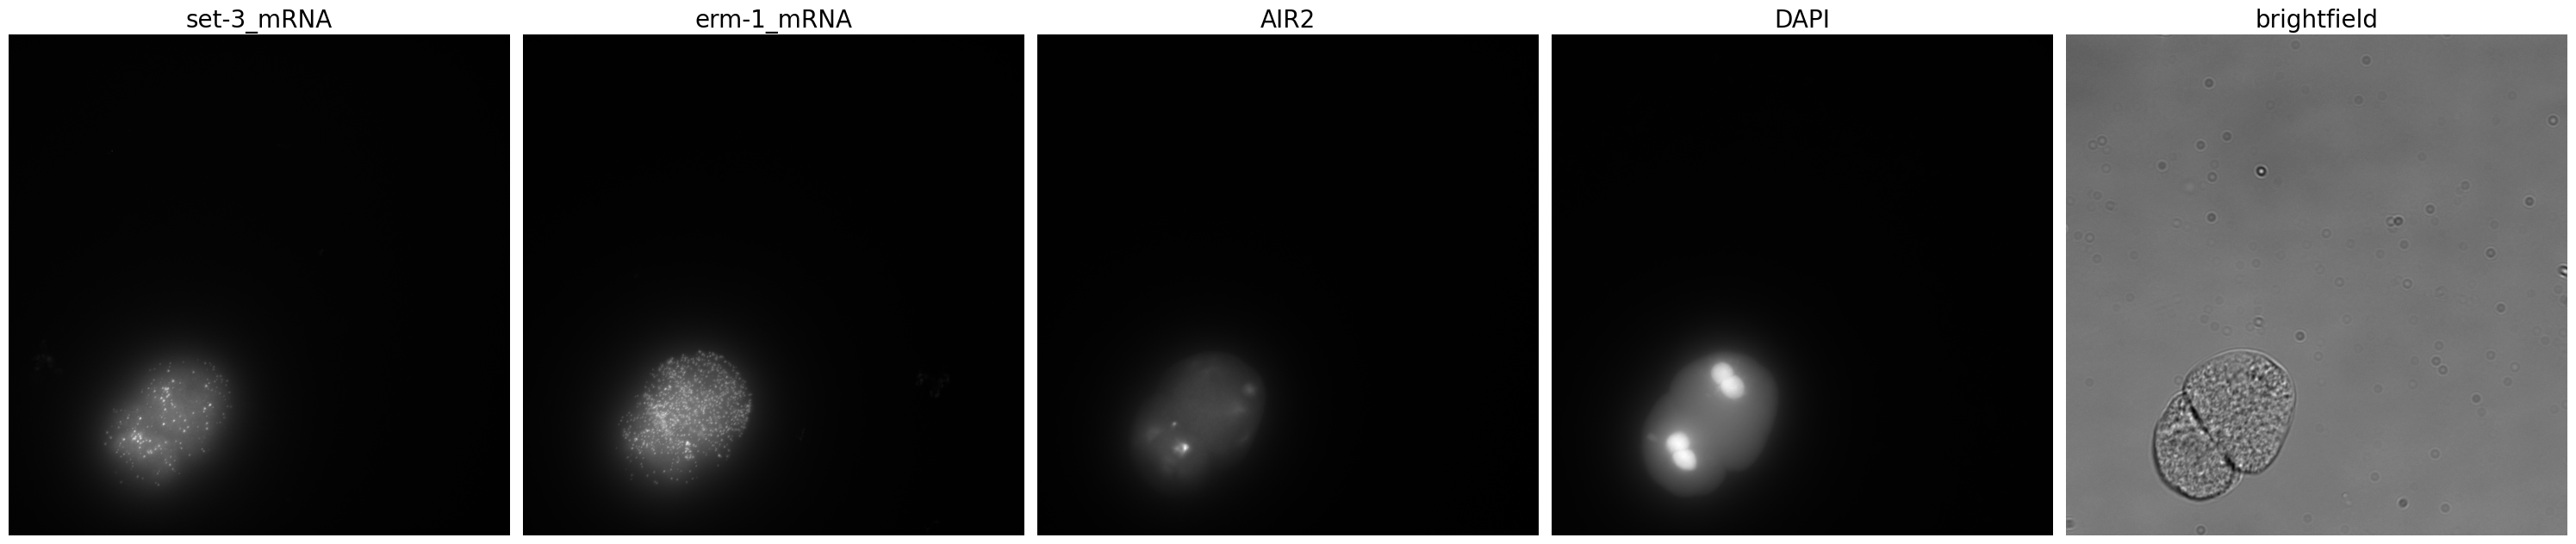

In [5]:
# #Read in Deltavision files

if dv_images:
    # Reading the microscopy data
    current_directory = os.getcwd()
    folder_path = os.path.join(current_directory, folder_name)

    if os.path.exists(folder_path):
        # List the files in the folder
        list_filenames = os.listdir(folder_path)
        list_filenames = sorted(list_filenames)
        path_files = [os.path.join(folder_path, filename) for filename in list_filenames if not filename.startswith('.ipynb_checkpoints')]

        # Read DV files and store image stacks in list_images
        list_images = []
        for image in path_files:
            image_stack = stack.read_dv(image)
            list_images.append(image_stack)

    # Extract Image ID by removing the "_R3D_REF.dv" suffix
    dv_filename = list_filenames[1]
    if dv_filename.endswith("_R3D_REF.dv"):
        image_name = dv_filename[:-len("_R3D_REF.dv")]
    else:
        image_name = dv_filename
    print(f'Image ID: {image_name}', '\n')

    # Converting the image to a specific shape
    bf = list_images[1]  # [C,Z,Y,X]
    image_colors = list_images[0]  # Reference [Y,X]

    bf = bf.astype(np.uint16)
    image_colors = image_colors.astype(np.uint16)

    print(f'Image colors \n{list_filenames[0]}: {image_colors.shape} \n')
    print(f'Brightfield \n{list_filenames[1]}: {bf.shape}')
        
        
    # Explicitly assign channels from image_colors and bf
    Cy5_array = image_colors[0, :, :, :] if image_colors[0] is not None else None
    mCherry_array = image_colors[1, :, :, :] if image_colors[1] is not None else None
    FITC_array = image_colors[2, :, :, :] if image_colors[2] is not None else None
    nuclei_array = image_colors[3, :, :, :] if image_colors[3] is not None else None
    bf = bf if brightfield is not None else None


    # Explicitly assign channels from image_colors and bf
    image_Cy5 = np.max(image_colors[0, :, :, :], axis=0) if image_colors[0] is not None else None
    image_mCherry = np.max(image_colors[1, :, :, :], axis=0) if image_colors[1] is not None else None
    image_FITC = np.max(image_colors[2, :, :, :], axis=0) if image_colors[2] is not None else None
    image_nuclei = np.max(image_colors[3, :, :, :], axis=0) if image_colors[3] is not None else None
    bf = bf if brightfield is not None else None

    # Combine images into a list
    images = [image_Cy5, image_mCherry, image_FITC, image_nuclei, bf]
    titles = [Cy5, mCherry, FITC, DAPI, brightfield]

    # Filter out None entries
    filtered_images = [(img, title) for img, title in zip(images, titles) if img is not None]

    # Plot the filtered images
    fig, ax = plt.subplots(1, len(filtered_images), figsize=(6 * len(filtered_images), 8))

    # Ensure ax is iterable
    if len(filtered_images) == 1:
        ax = [ax]

    for i, (img, title) in enumerate(filtered_images):
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(title, size=20)
        ax[i].axis("off")

    # Adjust layout and save the plot
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f'colors_{image_name}.png'))
    plt.show()
    plt.close()

    
    grid_width=80
    grid_height=80

In [6]:
# Process nd2 images

if nd2_images:
    # Reading the microscopy data
    current_directory = os.getcwd()
    folder_path = os.path.join(current_directory, folder_name)

    if os.path.exists(folder_path):
        # List the files in the folder
        list_filenames = os.listdir(folder_path)
        list_filenames = sorted(list_filenames)
        path_files = [
            os.path.join(folder_path, filename)
            for filename in list_filenames
            if not filename.startswith(".ipynb_checkpoints")
        ]

        # Read ND2 files and store image stacks in list_images
        list_images = []
        for image in path_files:
            image_stack = nd2.imread(image)  # Read ND2 image
            list_images.append(image_stack)

    # Extract Image ID
    image_name = list_filenames[0]
    print(f"Image ID: {image_name}\n")

    # Check the dimensions of the first image stack
    image_colors = list_images[0]  # Example shape: [T, C, Y, X]
    print(f"Image colors \n{list_filenames[0]}: {image_colors.shape}\n")


    # Define channel names and process max projections
    channels = [Cy5, mCherry, FITC, DAPI, brightfield]
    titles = channels

    # Explicitly assign channels from image_colors and bf
    Cy5_array = image_colors[:, 0, :, :] if image_colors[0] is not None else None
    mCherry_array = image_colors[:, 1, :, :] if image_colors[1] is not None else None
    FITC_array = image_colors[:, 2, :, :] if image_colors[2] is not None else None
    nuclei_array = image_colors[:, 3, :, :] if image_colors[3] is not None else None
    bf = image_colors[:, 4, :, :] if image_colors[4] is not None else None
    
    # Explicitly process each channel
    image_Cy5 = np.max(image_colors[:, 0, :, :], axis=0) if Cy5 else None
    image_mCherry = np.max(image_colors[:, 1, :, :], axis=0) if mCherry else None
    image_FITC = np.max(image_colors[:, 2, :, :], axis=0) if FITC else None
    image_nuclei = np.max(image_colors[:, 3, :, :], axis=0) if DAPI else None
    bf = np.max(image_colors[:, 4, :, :], axis=0) if brightfield else None ## something diff here

    # Combine the images into a list
    images = [image_Cy5, image_mCherry, image_FITC, image_nuclei, bf]

    # Filter out None entries
    filtered_images = [(img, title) for img, title in zip(images, titles) if img is not None]

    # Plotting the images
    fig, ax = plt.subplots(1, len(filtered_images), figsize=(6 * len(filtered_images), 8))

    # Ensure ax is always iterable, even if there's only one plot
    if len(filtered_images) == 1:
        ax = [ax]

    for i, (img, title) in enumerate(filtered_images):
        ax[i].imshow(img, cmap="gray")
        ax[i].set_title(title, size=20)
        ax[i].axis("off")

    # Adjust layout and save the plots in the results folder
    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, "colors_" + image_name + ".png"))
    plt.show()
    plt.close()

    
    grid_width=80
    grid_height=60


In [7]:
# # #Read .tif or .tiff images

# if tiff_images:
#     def tiff_images(mask_folder, output_directory, slice_to_plot=3):
#         current_directory = os.getcwd()
#         mask_path = os.path.join(current_directory, mask_folder)

#         if not os.path.exists(mask_path):
#             print("Folder does not exist.")
#             return

#         # List the files in the folder
#         list_filenames = sorted([
#             f for f in os.listdir(mask_path)
#             if f.endswith(".tif") or f.endswith(".tiff")
#         ])

#         path_files = [os.path.join(mask_path, filename) for filename in list_filenames]
#         list_images = [tiff.imread(image) for image in path_files]

#         # Extract Image ID
#         image_name = list_filenames[0]
#         print(f"Image ID: {image_name}\n")

#         # Load and rotate the first image (3D stack)
#         image_stack = list_images[0]
#         print(f"Image shape: {image_stack.shape}")
#         total_z = image_stack.shape[0]

#         # Rotate each Z-slice 90° clockwise and store in tif_mask
#         tif_mask_array = np.array([np.rot90(slice, k=1) for slice in image_stack])

#         # Plot the specified slice
#         plt.imshow(tif_mask_array[slice_to_plot], cmap='gray')
#         plt.title(f'Rotated Slice {slice_to_plot} of {total_z}')
#         plt.axis('off')
#         plt.show()

#         return #tif_mask_array  # Return the rotated mask for later use
#     tiff_images(mask_folder, output_directory, slice_to_plot=12)


### 1. Segmentation

#### 1.1 Single cell segmentation (up to 4-cell embryos)

In [54]:
#### 1.1 Single cell segmentation (up to 4-cell embryos)

model_path = "/projects/naly@colostate.edu/ce-bigfish/01_notebooks/models/ce-embryo"

# Additional functions used for segmentation
def is_nucleus_in_cytosol(mask_n, mask_c):
    mask_n[mask_n>1]=1
    mask_c[mask_c>1]=1
    size_mask_n = np.count_nonzero(mask_n)
    size_mask_c = np.count_nonzero(mask_c)
    min_size =np.min( (size_mask_n,size_mask_c) )
    mask_combined =  mask_n + mask_c
    sum_mask = np.count_nonzero(mask_combined[mask_combined==2])
    if (sum_mask> min_size*0.8) and (min_size>200): # the element is inside if the two masks overlap over the 80% of the smaller mask.
        return 1
    else:
        return 0
    
def remove_lonely_masks(masks_0, masks_1,is_nuc=None):
    n_mask_0 = np.max(masks_0)
    n_mask_1 = np.max(masks_1)
    if (n_mask_0>0) and (n_mask_1>0):
        for ind_0 in range(1,n_mask_0+1):
            tested_mask_0 = erosion(np.where(masks_0 == ind_0, 1, 0))
            array_paired= np.zeros(n_mask_1)
            for ind_1 in range(1,n_mask_1+1):
                tested_mask_1 = erosion(np.where(masks_1 == ind_1, 1, 0))
                array_paired[ind_1-1] = is_nucleus_in_cytosol(tested_mask_1, tested_mask_0)
                if (is_nuc =='nuc') and (np.count_nonzero(tested_mask_0) > np.count_nonzero(tested_mask_1) ):
                    # condition that rejects images with nucleus bigger than the cytosol
                    array_paired[ind_1-1] = 0
                elif (is_nuc is None ) and (np.count_nonzero(tested_mask_1) > np.count_nonzero(tested_mask_0) ):
                    array_paired[ind_1-1] = 0
            if any (array_paired) == False: # If the cytosol is not associated with any mask.
                masks_0 = np.where(masks_0 == ind_0, 0, masks_0)
            masks_with_pairs = masks_0
    else:
        masks_with_pairs = np.zeros_like(masks_0)
    return masks_with_pairs

def matching_masks(masks_cyto, masks_nuclei):
    n_mask_cyto = np.max(masks_cyto)
    n_mask_nuc = np.max(masks_nuclei)
    new_masks_nuclei = np.zeros_like(masks_cyto)
    reordered_mask_nuclei = np.zeros_like(masks_cyto)
    if (n_mask_cyto>0) and (n_mask_nuc>0):
        for mc in range(1,n_mask_cyto+1):
            tested_mask_cyto = np.where(masks_cyto == mc, 1, 0)
            for mn in range(1,n_mask_nuc+1):
                mask_paired = False
                tested_mask_nuc = np.where(masks_nuclei == mn, 1, 0)
                mask_paired = is_nucleus_in_cytosol(tested_mask_nuc, tested_mask_cyto)
                if mask_paired == True:
                    if np.count_nonzero(new_masks_nuclei) ==0:
                        new_masks_nuclei = np.where(masks_nuclei == mn, -mc, masks_nuclei)
                    else:
                        new_masks_nuclei = np.where(new_masks_nuclei == mn, -mc, new_masks_nuclei)
            reordered_mask_nuclei = np.absolute(new_masks_nuclei)
    return reordered_mask_nuclei

def remove_extreme_values(image,min_percentile=0.1, max_percentile=99.5):
    max_val = np.percentile(image, max_percentile)
    min_val = np.percentile(image, min_percentile)
    image [image < min_val] = min_val
    image [image > max_val] = max_val
    return image

def metric_max_cells_and_area( masks):
    n_masks = np.max(masks)
    if n_masks > 1: # detecting if more than 1 mask are detected per cell
        size_mask = []
        for nm in range (1, n_masks+1): # iterating for each mask in a given cell. The mask has values from 0 for background, to int n, where n is the number of detected masks.
            approximated_radius = np.sqrt(np.sum(masks == nm)/np.pi)  # a=  pi r2
            size_mask.append(approximated_radius) #np.sum(masks == nm)) # creating a list with the size of each mask
        size_masks_array = np.array(size_mask)
        metric = np.mean(size_masks_array).astype(int) * n_masks
    elif n_masks == 1: # do nothing if only a single mask is detected per image.
        approximated_radius = np.sqrt(np.sum(masks == 1)/np.pi) 
        metric = approximated_radius.astype(int)
    else:  # return zero if no mask are detected
        metric = 0  
    return metric   


def nuclear_segmentation(image_nuclei):
    
    # Run Cellpose for nuclei (smaller, multiple objects)
    model_nuclei = models.Cellpose(model_type='cyto2')
    
    # Cellpose expects a 2D or 3D array; diameter can be adjusted
    masks_nuclei, flows, styles, diams = model_nuclei.eval(
        image_nuclei,
        diameter=50,           # approximate nucleus diameter in pixels
        channels=[0, 0],       # grayscale: [nuclei_channel, cytoplasm_channel], here only nuclei
        cellprob_threshold=0.0,
        flow_threshold=0.5
    )
    
    # Ensure masks are labeled sequentially (0=background)
    unique_labels = np.unique(masks_nuclei)
    labeled_masks = np.zeros_like(masks_nuclei)
    for idx, lbl in enumerate(unique_labels):
        if lbl == 0:
            continue
        labeled_masks[masks_nuclei == lbl] = idx
    
    masks_nuclei = labeled_masks
    return masks_nuclei


def cytosol_segmentation(image_cytosol,second_image_cytosol,cytosol_diameter):
    flow_ts=1 #try 0.4
    MIN_CELL_SIZE = 200 #100000 -> segmented the entire embryo
    #model = models.Cellpose(gpu=True, model_type='cyto2') # model_type='cyto', 'cyto2' or model_type='nuclei'
    model = models.CellposeModel(gpu=True, pretrained_model=model_path)
    if not (second_image_cytosol is None):
        merged_image_cytosol = np.concatenate((image_cytosol[:, :, np.newaxis], second_image_cytosol[:, :, np.newaxis]), axis=2)
        masks_cytosol_unfiltered = model.eval(merged_image_cytosol, diameter=cytosol_diameter, flow_threshold=flow_ts, channels=[0,0])[0]
    else:
        masks_cytosol_unfiltered = model.eval(image_cytosol, diameter=cytosol_diameter, flow_threshold=flow_ts, channels=[0,0])[0]
    filtered_cyto = morphology.remove_small_objects(masks_cytosol_unfiltered, min_size=MIN_CELL_SIZE)
    unique_filtered_cyto = np.unique(filtered_cyto)
    masks_cytosol = np.zeros_like(filtered_cyto)
    for idx, old_label in enumerate(unique_filtered_cyto):
        masks_cytosol[filtered_cyto == old_label] = idx
    return masks_cytosol

def segmentation_optimization(image_cytosol,image_nuclei,cytosol_diameter,second_image_cytosol=None):
    # Cytosol segmentation
    masks_cytosol =cytosol_segmentation(image_cytosol,second_image_cytosol,cytosol_diameter)
    # Nuclear segmentation
    masks_nuclei = nuclear_segmentation(image_nuclei)
    # reordering nuclei masks
    masks_nuclei = matching_masks(masks_cytosol,masks_nuclei)
    # remove masks without nuclei
    masks_nuclei= remove_lonely_masks(masks_0=masks_nuclei , masks_1=masks_cytosol,is_nuc='nuc')
    masks_cytosol= remove_lonely_masks(masks_0=masks_cytosol , masks_1=masks_nuclei)
    # calculate size of masks
    number_masks_cyto = np.max(masks_cytosol)
    list_masks_cyto_sizes =[]
    for i in range (1, number_masks_cyto+1):
        list_masks_cyto_sizes.append(len(masks_cytosol[masks_cytosol==i]) )
    number_masks_nuc = np.max(masks_nuclei)
    list_masks_nuc_sizes =[]
    for i in range (1, number_masks_nuc+1):
        list_masks_nuc_sizes.append(len(masks_nuclei[masks_nuclei==i]) )
    return masks_nuclei, masks_cytosol,list_masks_nuc_sizes, list_masks_cyto_sizes


# Codes used to segment the nucleus and the cytosol
def segmentation(image_cytosol,image_nuclei, second_image_cytosol=None):
    # removing outliers in image
    image_cytosol = remove_extreme_values(image=image_cytosol,min_percentile=0.1, max_percentile=99.5)
    if not (second_image_cytosol is None):
        second_image_cytosol = remove_extreme_values(image=second_image_cytosol,min_percentile=0.1, max_percentile=99.5)
    image_nuclei = remove_extreme_values(image=image_nuclei,min_percentile=0.1, max_percentile=99.5)
    # Optimization segmentation
    list_masks_nuclei = []
    list_masks_cytosol=[]
    list_masks_nuc_sizes =[]
    list_masks_cyto_sizes=[]
    list_flow_thresholds = np.arange(40, 200, 10)
    array_number_detected_masks = np.zeros(len(list_flow_thresholds))
    for i,tested_ts in enumerate(list_flow_thresholds):
        tested_masks_nuclei, tested_masks_cytosol, tested_list_masks_nuc_sizes, tested_list_masks_cyto_sizes = segmentation_optimization(image_cytosol,image_nuclei,cytosol_diameter=tested_ts,second_image_cytosol=second_image_cytosol)
        list_masks_nuclei.append(tested_masks_nuclei)
        list_masks_cytosol.append(tested_masks_cytosol)
        list_masks_nuc_sizes.append(tested_list_masks_nuc_sizes)
        list_masks_cyto_sizes.append(tested_list_masks_cyto_sizes)
        array_number_detected_masks[i]= metric_max_cells_and_area( tested_masks_cytosol) + metric_max_cells_and_area( tested_masks_nuclei)
    selected_index = np.argmax(array_number_detected_masks)
    masks_nuclei = list_masks_nuclei [selected_index]
    masks_cytosol = list_masks_cytosol [selected_index]
    masks_nuc_sizes = list_masks_nuc_sizes[selected_index]
    masks_cyto_sizes = list_masks_cyto_sizes[selected_index]
    
        # Plotting
    color_map = 'Greys_r'
    fig, ax = plt.subplots(1,4, figsize=(14, 4))
    # Plotting the heatmap of a section in the image
    ax[0].imshow(image_nuclei,cmap=color_map)
    ax[1].imshow(masks_nuclei,cmap=color_map)
    ax[2].imshow(image_cytosol,cmap=color_map)
    ax[3].imshow(masks_cytosol,cmap=color_map)
    ax[0].set(title='DAPI'); ax[0].axis('off');ax[0].grid(False)
    ax[1].set(title='mask nuclei'); ax[1].axis('off');ax[1].grid(False)
    ax[2].set(title='brightfield'); ax[2].axis('off');ax[2].grid(False)
    ax[3].set(title='mask cytosol'); ax[3].axis('off');ax[3].grid(False)


    return masks_cytosol, masks_nuclei, masks_cyto_sizes, masks_nuc_sizes

Cell segmentation took 1.31 minutes.
Cell segmentation finished. Skipping embryo segmentation.


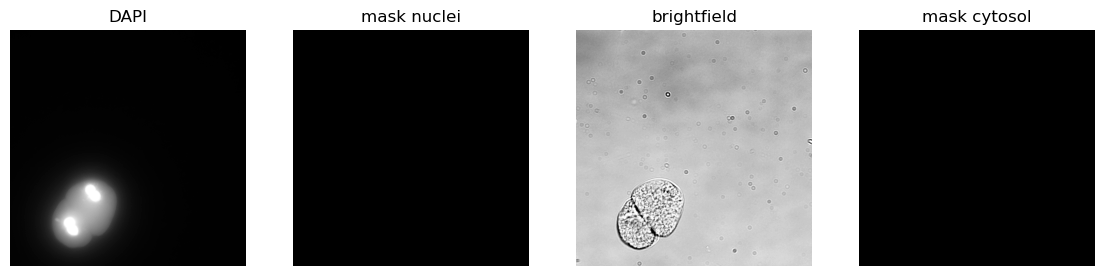

In [55]:
# # Run segmentation functions
# if run_cell_segmentation:
#     image_cytosol = bf
#     second_image_cytosol = image_nuclei
#     masks_cytosol, masks_nuclei,list_masks_cyto_sizes, list_masks_nuc_sizes = segmentation(image_cytosol,image_nuclei,second_image_cytosol)

#     segmentation_filename = os.path.join(output_directory, 'cell_segmentation_' + image_name + '.png')

#     # Save the figure
#     plt.savefig(segmentation_filename)



###### # Run cell segmentation function but default to embryo segmentation if longer than 10 min (time coditional):

if run_cell_segmentation:
    try:
        start_time = time.time()

        image_cytosol = bf
        second_image_cytosol = image_nuclei
        masks_cytosol, masks_nuclei, list_masks_cyto_sizes, list_masks_nuc_sizes = segmentation(
            image_cytosol, image_nuclei, second_image_cytosol
        )

        # Save segmentation figure
        segmentation_filename = os.path.join(output_directory, f'cell_segmentation_{image_name}.png')
        plt.savefig(segmentation_filename)

        elapsed_time = time.time() - start_time
        print(f"Cell segmentation took {elapsed_time / 60:.2f} minutes.")

        if elapsed_time > 600:
            print("Cell segmentation timed out. Proceeding to embryo segmentation.")
            run_embryo_segmentation = True
        else:
            print("Cell segmentation finished. Skipping embryo segmentation.")
            run_embryo_segmentation = False

    except Exception as e:
        print(f"Cell segmentation failed with error: {e}")
        print("Running embryo segmentation...")
        run_embryo_segmentation = False


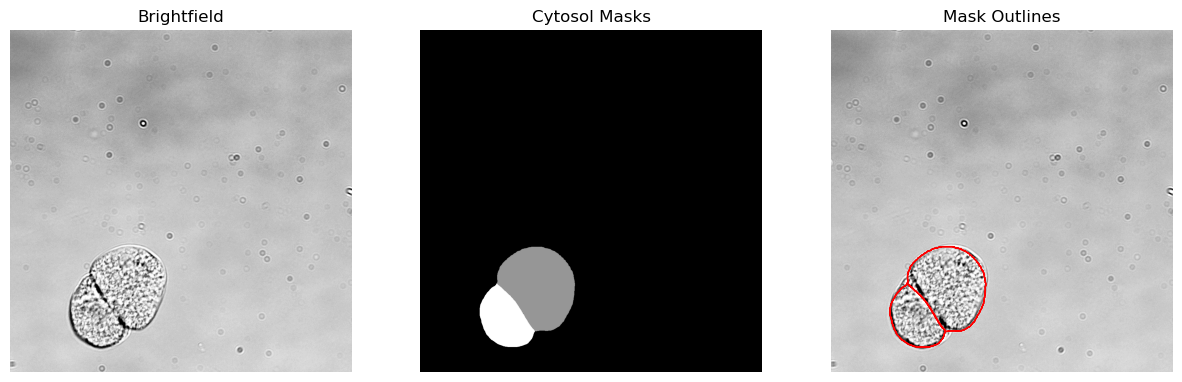

Cell segmentation took 0.06 minutes.
Cell segmentation finished. Skipping embryo segmentation.


<Figure size 640x480 with 0 Axes>

In [63]:
model_path = "/projects/naly@colostate.edu/ce-bigfish/01_notebooks/models/ce-embryo"

from skimage import morphology
from skimage.segmentation import find_boundaries
import matplotlib.pyplot as plt
import numpy as np
from cellpose import models

def remove_extreme_values(image, min_percentile=0.1, max_percentile=99.5):
    max_val = np.percentile(image, max_percentile)
    min_val = np.percentile(image, min_percentile)
    image = np.clip(image, min_val, max_val)
    return image

def cytosol_segmentation(image_cytosol, second_image_cytosol=None, cytosol_diameter=200):
    # Remove extreme pixel values
    image_cytosol = remove_extreme_values(image_cytosol)

    # Load pretrained BF-only model
    model = models.CellposeModel(gpu=True, pretrained_model=model_path)
    masks_raw = model.eval(image_cytosol, diameter=cytosol_diameter, channels=[0,0])[0]

    # Remove tiny objects
    MIN_CELL_SIZE = 200
    masks_filtered = morphology.remove_small_objects(masks_raw, min_size=MIN_CELL_SIZE)

    # Relabel sequentially
    unique_labels = np.unique(masks_filtered)
    masks_cytosol = np.zeros_like(masks_filtered)
    for idx, lbl in enumerate(unique_labels):
        if lbl == 0:
            continue
        masks_cytosol[masks_filtered == lbl] = idx

    # Calculate mask sizes
    mask_sizes = [np.sum(masks_cytosol == i) for i in range(1, np.max(masks_cytosol)+1)]

    # Create outline masks
    outline_masks = find_boundaries(masks_cytosol, mode='outer').astype(int)

    return masks_cytosol, mask_sizes, outline_masks

def segmentation(image_cytosol, image_nuclei=None, second_image_cytosol=None, cytosol_diameter=200):
    """
    Wrapper function to match original signature.
    Ignores nuclear segmentation entirely.
    Returns:
        masks_cytosol, None, mask_sizes, None
    """
    masks_cytosol, mask_sizes, outline_masks = cytosol_segmentation(
        image_cytosol, second_image_cytosol, cytosol_diameter
    )

    # Optional plotting
    color_map = 'Greys_r'
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(image_cytosol, cmap=color_map)
    ax[0].set(title='Brightfield'); ax[0].axis('off')
    
    ax[1].imshow(masks_cytosol, cmap=color_map)
    ax[1].set(title='Cytosol Masks'); ax[1].axis('off')

    ax[2].imshow(image_cytosol, cmap=color_map)
    ax[2].contour(outline_masks, colors='r', linewidths=0.5)
    ax[2].set(title='Mask Outlines'); ax[2].axis('off')

    plt.show()

    return masks_cytosol, None, mask_sizes, None

# # Example call
# masks_cytosol, masks_nuclei, list_masks_cyto_sizes, list_masks_nuc_sizes = segmentation(bf, image_nuclei)

if run_cell_segmentation:
    try:
        start_time = time.time()

        image_cytosol = bf
        second_image_cytosol = image_nuclei
        masks_cytosol, masks_nuclei, list_masks_cyto_sizes, list_masks_nuc_sizes = segmentation(
            image_cytosol, image_nuclei, second_image_cytosol
        )

        # Save segmentation figure
        segmentation_filename = os.path.join(output_directory, f'cell_segmentation_{image_name}.png')
        plt.savefig(segmentation_filename)

        elapsed_time = time.time() - start_time
        print(f"Cell segmentation took {elapsed_time / 60:.2f} minutes.")

        if elapsed_time > 600:
            print("Cell segmentation timed out. Proceeding to embryo segmentation.")
            run_embryo_segmentation = True
        else:
            print("Cell segmentation finished. Skipping embryo segmentation.")
            run_embryo_segmentation = False

    except Exception as e:
        print(f"Cell segmentation failed with error: {e}")
        print("Running embryo segmentation...")
        run_embryo_segmentation = False


### Cell stage sorting

In [12]:
import numpy as np
from skimage.measure import label, regionprops

def get_cell_stage_and_size_filtered(masks_nuclei, min_fraction_median=0.2):
    # Label connected components
    labeled_mask, num_nuclei = label(masks_nuclei, return_num=True)
    
    # XY pixel size in nm
    pixel_size_xy = voxel_size[1]
    
    # First pass: get all areas
    all_areas = np.array([region.area for region in regionprops(labeled_mask)])
    if len(all_areas) == 0:
        print("No nuclei detected")
        return None, []
    
    median_area = np.median(all_areas)
    min_area_pixels = median_area * min_fraction_median  # dynamically filter small outliers
    
    # Map number of nuclei to stage (after filtering)
    filtered_mask = np.zeros_like(labeled_mask)
    nuclei_sizes = []
    label_idx = 1
    for region in regionprops(labeled_mask):
        if region.area < min_area_pixels:
            continue  # skip very small outliers
        
        # keep in filtered mask
        filtered_mask[labeled_mask == region.label] = label_idx
        
        # Approximate diameter in pixels (assume circular)
        diameter_pixels = 2 * np.sqrt(region.area / np.pi)
        area_um2 = region.area * (pixel_size_xy / 1000)**2
        diameter_um = diameter_pixels * (pixel_size_xy / 1000)
        
        nuclei_sizes.append({
            "label": label_idx,
            "area_pixels": region.area,
            "diameter_pixels": diameter_pixels,
            "area_um2": area_um2,
            "diameter_um": diameter_um
        })
        label_idx += 1
    
    # Determine cell stage based on filtered nuclei
    num_filtered = len(nuclei_sizes)
    stage_map = {1: "1-cell", 2: "2-cell", 4: "4-cell"}
    stage = stage_map.get(num_filtered, f"{num_filtered}-cell (unmapped)")
    
    print(f"Detected {num_filtered} nuclei after filtering → Stage: {stage}")
    
    return stage, nuclei_sizes, filtered_mask

# Example usage
cell_stage, nuclei_sizes, masks_filtered = get_cell_stage_and_size_filtered(masks_nuclei)


# Your classifier logic
run_2cell_classifier = False
run_4cell_classifier = False
run_embryo_segmentation = False

if run_cell_classifier:
    if cell_stage == "2-cell":
        run_2cell_classifier = True
    elif cell_stage == "4-cell":
        run_4cell_classifier = True
    elif int(cell_stage.split('-')[0]) > 4:
        run_embryo_segmentation = True

print(f"run_2cell_classifier = {run_2cell_classifier}")
print(f"run_4cell_classifier = {run_4cell_classifier}")
print(f"run_embryo_segmentation = {run_embryo_segmentation}")


Detected 2 nuclei after filtering → Stage: 2-cell
run_2cell_classifier = True
run_4cell_classifier = False
run_embryo_segmentation = False


#### Classify masks with biological names

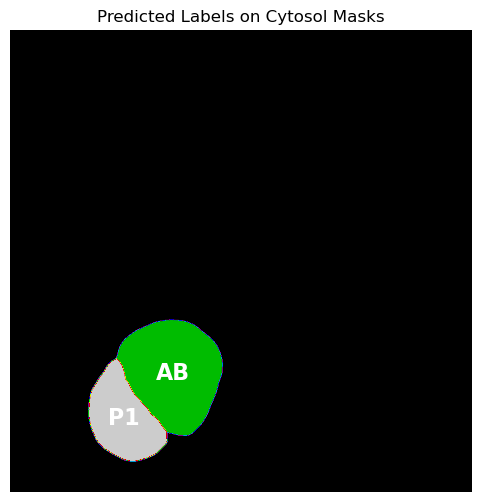

   label     area   perimeter  eccentricity  solidity    extent  \
0      1  42003.0  794.891486      0.573138  0.987284  0.695471   
1      2  23809.0  646.908730      0.793098  0.943790  0.594111   

   major_axis_length  minor_axis_length  mean_intensity  bbox-0  ...  bbox-3  \
0         258.280026         211.649776     1382.913982     642  ...     471   
1         230.165161         140.192375     1339.425511     727  ...     349   

   centroid-0  centroid-1  orientation  initial_prediction  \
0  759.175868  360.787134     0.430928                  AB   
1  859.803730  250.687219     0.506930                  P1   

   prediction_confidence AB_conf  P1_conf  highest_confidence_label  \
0                   0.83    0.83     0.17                        AB   
1                   0.99    0.01     0.99                        P1   

   nearby_cells  
0          True  
1          True  

[2 rows x 22 columns]


In [14]:
### 2-cell classifier


# Suppress just the InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

if run_2cell_classifier:
    # --- Extract features of unseen brightfield image for classification ---
    props_unseen = regionprops_table(
        masks_cytosol,
        intensity_image=bf,
        properties=[
            'label', 'area', 'perimeter', 'eccentricity', 'solidity', 'extent',
            'major_axis_length', 'minor_axis_length', 'mean_intensity',
            'bbox', 'centroid', 'orientation'
        ]
    )

    # Convert to DataFrame
    features_df = pd.DataFrame(props_unseen)

    # Load trained Random Forest model
    rf = joblib.load("models/RF_classification/2-cell_classification_RFmodel.joblib")

    # --- Select the features used during training ---
    X_new = features_df[
        [
            'area', 'perimeter', 'eccentricity', 'solidity', 'extent',
            'major_axis_length', 'minor_axis_length', 'mean_intensity',
            'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3',
            'centroid-0', 'centroid-1',
            'orientation'
        ]
    ]

    # --- Predict cell type and probabilities ---
    predictions = rf.predict(X_new)
    proba = rf.predict_proba(X_new)
    classes = rf.classes_

    # Initial predicted labels
    initial_preds = rf.predict(X_new)

    # --- Get confidence scores ---
    predicted_class_indices = [list(classes).index(pred) for pred in initial_preds]
    prediction_confidence = [proba[i][idx] for i, idx in enumerate(predicted_class_indices)]

    # Add predictions and confidence to dataframe
    features_df["initial_prediction"] = initial_preds
    features_df["prediction_confidence"] = prediction_confidence

    # ---- Fail-safe logic: Ensure exactly one AB and one P1 ----
    # Get confidence for each class separately
    ab_idx = list(classes).index("AB")
    p1_idx = list(classes).index("P1")

    # Rank cells by their AB and P1 confidence
    features_df["AB_conf"] = proba[:, ab_idx]
    features_df["P1_conf"] = proba[:, p1_idx]

    # Assign highest AB_conf as AB, highest P1_conf as P1
    ab_row = features_df.loc[features_df["AB_conf"].idxmax()]
    p1_row = features_df.loc[features_df["P1_conf"].idxmax()]

    # Assign labels
    features_df["highest_confidence_label"] = "Unassigned"
    features_df.loc[ab_row.name, "highest_confidence_label"] = "AB"
    features_df.loc[p1_row.name, "highest_confidence_label"] = "P1"
    
    # --- Extract AB and P1 masks from masks_cytosol ---
    ab_mask = (masks_cytosol == ab_row['label'])
    p1_mask = (masks_cytosol == p1_row['label'])

    # Dilate slightly to ensure boundary contact detection
    ab_dilated = binary_dilation(ab_mask, iterations=1)
    p1_dilated = binary_dilation(p1_mask, iterations=1)

    # Check whether AB and P1 touch
    touching = np.any(ab_dilated & p1_mask) or np.any(p1_dilated & ab_mask)

    if not touching:
        print(f"Fail-safe triggered for {image_name}: AB and P1 are not touching.")
        # Strict option: unassign both
        features_df.loc[ab_row.name, "highest_confidence_label"] = "Unassigned"
        features_df.loc[p1_row.name, "highest_confidence_label"] = "Unassigned"
        features_df["nearby_cells"] = False
    else:
        features_df["nearby_cells"] = True


    # --- Plot prediction labels ---
    mask_image = np.max(masks_cytosol, axis=0) if masks_cytosol.ndim == 3 else masks_cytosol
    plt.figure(figsize=(6, 6))
    plt.imshow(mask_image, cmap='nipy_spectral')
    plt.axis('off')

    # Loop over each object to overlay predicted label text
    for idx, row in features_df.iterrows():
        label = row['label']  # mask label number
        pred_label = row['highest_confidence_label']  # predicted class label (e.g., 'AB' or 'P1')

        # Compute centroid of the labeled region
        y, x = center_of_mass(mask_image == label)

        # Overlay predicted label text on centroid
        plt.text(x, y, pred_label, color='white', fontsize=16,
                 ha='center', va='center', weight='bold')

    plt.title("Predicted Labels on Cytosol Masks")

    # --- Save outputs ---
    features_df_output = os.path.join(output_directory, f'features_df_{image_name}.csv')
    features_df.to_csv(features_df_output, index=False)

    predicted_label_filename = os.path.join(output_directory, f'predicted_label_{image_name}.png')
    plt.savefig(predicted_label_filename, dpi=300, bbox_inches='tight')
    plt.show()

print(features_df.tail())


In [15]:
### 4-cell classifier
from skimage import filters
from skimage.util import img_as_float
import seaborn as sns
import matplotlib.pyplot as plt


# Suppress just the InconsistentVersionWarning
warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

if run_4cell_classifier:
    # --- Extract base features ---
    props_unseen = regionprops_table(
        masks_cytosol,
        intensity_image=bf,
        properties=[
            'label', 'area', 'perimeter', 'eccentricity', 'solidity', 'extent',
            'major_axis_length', 'minor_axis_length', 'mean_intensity',
            'bbox', 'centroid', 'orientation'
        ]
    )
    features_df = pd.DataFrame(props_unseen)
    # --- define centroid_x / centroid_y ---
    features_df['centroid_y'] = features_df['centroid-0']
    features_df['centroid_x'] = features_df['centroid-1']

    # --- Apply filters once to whole BF image ---
    bf_float = img_as_float(bf)
    smooth = filters.gaussian(bf_float, sigma=1)
    sobel_edges = filters.sobel(smooth)
    median_filtered = filters.rank.median(
        (bf / bf.max() * 255).astype(np.uint8),
        disk(3)
    )

    # --- Add per-cell filtered stats ---
    extra_features = []
    for lbl in features_df['label']:
        mask = (masks_cytosol == lbl)
        extra_features.append({
            "smooth_mean": np.mean(smooth[mask]),
            "smooth_std": np.std(smooth[mask]),
            "smooth_median": np.median(smooth[mask]),
            "sobel_mean": np.mean(sobel_edges[mask]),
            "sobel_std": np.std(sobel_edges[mask]),
            "sobel_median": np.median(sobel_edges[mask]),
            "medianf_mean": np.mean(median_filtered[mask]),
            "medianf_std": np.std(median_filtered[mask]),
            "medianf_median": np.median(median_filtered[mask])
        })
    extra_df = pd.DataFrame(extra_features)
    features_df = pd.concat([features_df, extra_df], axis=1)

    # --- Load model ---
    rf = joblib.load("models/RF_classification/4-cell_classification_RFmodel.joblib")

    # --- Match training feature order ---
    X_new = features_df[
        [
            'area', 'perimeter', 'eccentricity', 'solidity', 'extent',
            'major_axis_length', 'minor_axis_length', 'mean_intensity',
            'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3',
            'centroid-0', 'centroid-1',
            'orientation',
            'smooth_mean', 'smooth_std', 'smooth_median',
            'sobel_mean', 'sobel_std', 'sobel_median',
            'medianf_mean', 'medianf_std', 'medianf_median'
        ]
    ]

    # --- Predict ---
    proba = rf.predict_proba(X_new)
    classes = rf.classes_
    initial_preds = rf.predict(X_new)

    # --- Confidence scores ---
    predicted_class_indices = [list(classes).index(pred) for pred in initial_preds]
    prediction_confidence = [proba[i][idx] for i, idx in enumerate(predicted_class_indices)]
    features_df["initial_prediction"] = initial_preds
    features_df["prediction_confidence"] = prediction_confidence

    # --- Confidence for each class ---
    for cname in ["ABa", "ABb", "EMS", "P2"]:
        features_df[f"{cname}_conf"] = proba[:, list(classes).index(cname)]

    # --- Fail-safe: ensure one label per class ---
    features_df["highest_confidence_label"] = "Unassigned"
    for cname in ["ABa", "ABb", "EMS", "P2"]:
        features_df.loc[features_df[f"{cname}_conf"].idxmax(), "highest_confidence_label"] = cname

    # --- Positional fail-safe using ellipse ---
    # Fit ellipse to entire embryo
    binary_image = (masks_cytosol > 0).astype(np.uint8)
    contours = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    if contours and len(contours[0]) >= 5:
        cnt = max(contours, key=cv2.contourArea)
        ellipse = cv2.fitEllipse(cnt)
        (xc, yc), (d1, d2), angle = ellipse  # center, axes, rotation
        theta = np.deg2rad(angle)
        minor_axis_vec = np.array([-np.sin(theta), np.cos(theta)])  # along minor axis

        # Compute relative minor-axis positions for each cell
        rel_positions = []
        for idx, row in features_df.iterrows():
            centroid = np.array([row['centroid_x'], row['centroid_y']])
            vec_from_center = centroid - np.array([xc, yc])
            rel_pos_minor = np.dot(vec_from_center, minor_axis_vec) / d2  # normalized
            rel_positions.append(rel_pos_minor)
        features_df['rel_pos_minor'] = rel_positions

        # Assign ABa / P2 at ends
        left_cell = features_df.loc[features_df['rel_pos_minor'].idxmin()]
        right_cell = features_df.loc[features_df['rel_pos_minor'].idxmax()]
        if left_cell['area'] > right_cell['area']:
            features_df.loc[left_cell.name, 'highest_confidence_label'] = 'ABa'
            features_df.loc[right_cell.name, 'highest_confidence_label'] = 'P2'
        else:
            features_df.loc[left_cell.name, 'highest_confidence_label'] = 'P2'
            features_df.loc[right_cell.name, 'highest_confidence_label'] = 'ABa'

        # Middle cells: EMS = smaller, ABb = larger
        middle_cells = features_df.drop([left_cell.name, right_cell.name])
        ems_cell = middle_cells.loc[middle_cells['area'].idxmin()]
        abb_cell = middle_cells.loc[middle_cells['area'].idxmax()]
        features_df.loc[ems_cell.name, 'highest_confidence_label'] = 'EMS'
        features_df.loc[abb_cell.name, 'highest_confidence_label'] = 'ABb'

    # --- Plot results ---
    mask_image = np.max(masks_cytosol, axis=0) if masks_cytosol.ndim == 3 else masks_cytosol
    plt.figure(figsize=(6, 6))
    plt.imshow(mask_image, cmap='nipy_spectral')
    plt.axis('off')

    for idx, row in features_df.iterrows():
        y, x = center_of_mass(mask_image == row['label'])
        plt.text(x, y, row['highest_confidence_label'], color='white',
                 fontsize=16, ha='center', va='center', weight='bold')

    plt.title("Predicted Labels on Cytosol Masks")

    # --- Save outputs ---
    features_df_output = os.path.join(output_directory, f'features_df_{image_name}.csv')
    features_df.to_csv(features_df_output, index=False)
    predicted_label_filename = os.path.join(output_directory, f'predicted_label_{image_name}.png')
    plt.savefig(predicted_label_filename, dpi=300, bbox_inches='tight')
    plt.show()

    print(features_df.tail())

   ## plot cell centroid position
    plt.figure(figsize=(6,6))
    for label, group in features_df.groupby('highest_confidence_label'):
        plt.scatter(group['centroid_x'], group['centroid_y'], 
                    s=group['area']/50, label=label)

    plt.gca().invert_yaxis()  # Match image coordinates
    plt.xlabel("X position")
    plt.ylabel("Y position")
    plt.legend()
    plt.title("Cell positions and sizes")
    plt.show()


    ### plot prediction confidence per cell
    # Reshape dataframe for plotting
    conf_cols = ['ABa_conf', 'ABb_conf', 'EMS_conf', 'P2_conf']
    conf_df = features_df.melt(id_vars='label', value_vars=conf_cols,
                               var_name='class', value_name='confidence')

    # Strip "_conf" from class names
    conf_df['class'] = conf_df['class'].str.replace('_conf','')

    plt.figure(figsize=(8,4))
    sns.barplot(data=conf_df, x='label', y='confidence', hue='class')
    plt.ylabel("Classifier Confidence")
    plt.xlabel("Cell Mask Label")
    plt.title("Confidence Scores per Cell and Class")
    plt.legend(title="Class")
    plt.show()


#### 2.2 Embryo Segemntation

In [16]:
## Embryo segmentation
from cellpose import models, utils
import matplotlib.pyplot as plt
import numpy as np
from skimage import measure   
from skimage.draw import polygon2mask
from skimage.measure import regionprops, label


def keep_largest_region(mask):
    labels = measure.label(mask)
    props = measure.regionprops(labels)
    if not props:
        return mask * 0  # return empty if nothing found
    largest_region = max(props, key=lambda x: x.area)
    return (labels == largest_region.label).astype(np.uint16)

def embryo_segmentation(bf, image_nuclei, image_name, output_directory):
    cytosol_image = bf[..., 0] if bf.ndim == 3 else bf
    nuclei_image = image_nuclei[..., 0] if image_nuclei.ndim == 3 else image_nuclei

    # Run Cellpose for cytosol (large object: the embryo)
    model_cyto = models.Cellpose(model_type='cyto')
    masks_cytosol, _, _, _ = model_cyto.eval(
        cytosol_image, diameter=embryo_diameter, channels=[0, 0]
    )
    masks_cytosol = keep_largest_region(masks_cytosol)

    # Run Cellpose for nuclei (smaller, multiple objects)
    model_nuclei = models.Cellpose(model_type='cyto2')
    masks_nuclei, _, _, _ = model_nuclei.eval(
        nuclei_image, diameter=50, channels=[0, 0],
        cellprob_threshold=0.0, flow_threshold=0.5
    )

    # Get outlines
    outlines_cytosol = utils.outlines_list(masks_cytosol)
    outlines_nuclei = utils.outlines_list(masks_nuclei)

    # Compute sizes
    labeled_cyto = label(masks_cytosol.astype(np.uint16))
    labeled_nuc = label(masks_nuclei.astype(np.uint16))
    masks_cyto_sizes = [prop.area for prop in regionprops(labeled_cyto)]
    masks_nuc_sizes = [prop.area for prop in regionprops(labeled_nuc)]

    # Plot side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    ax[0].imshow(cytosol_image, cmap='gray')
    for o in outlines_cytosol:
        ax[0].plot(o[:, 0], o[:, 1], color='lime', linewidth=1)
    ax[0].set_title('Embryo Mask')
    ax[0].axis('off')

    ax[1].imshow(nuclei_image, cmap='gray')
    for o in outlines_nuclei:
        ax[1].plot(o[:, 0], o[:, 1], color='deepskyblue', linewidth=1)
    ax[1].set_title('Nuclei Mask')
    ax[1].axis('off')

    # Create binary mask for embryo outline
    image_shape = cytosol_image.shape
    embryo_outline = np.zeros(image_shape, dtype=bool)
    for outline in outlines_cytosol:
        poly_mask = polygon2mask(image_shape, outline[:, ::-1])
        embryo_outline |= poly_mask

    # Save figure
    segmentation_filename = os.path.join(output_directory, f'embryo_segmentation_{image_name}.png')
    plt.savefig(segmentation_filename)
    plt.tight_layout()
    plt.show()
    plt.close()

    return masks_cytosol, masks_nuclei, masks_cyto_sizes, masks_nuc_sizes


if run_embryo_segmentation:
    masks_cytosol, masks_nuclei, masks_cyto_sizes, masks_nuc_sizes = embryo_segmentation(
        bf, image_nuclei, image_name, output_directory
    )


In [17]:
# def get_features_from_masks(img, masks):
    
#     valid_masks = []
#     for i in range(1,np.max(masks)+1):
#         if (masks == i).sum()!=0:
#             valid_masks.append(i)
            
#     features = np.zeros([1, len(valid_masks)])
#     print(valid_masks)
#     for n in range(len(valid_masks)):
#         features[0,n] = np.mean(img[4]*(masks==valid_masks[n]))
#     return features

# get_features_from_masks(image_colors, masks_cytosol)

### 2. Spot detection

#### 2.1 Spot detection (automated threshold selection and spot detection)

In [ ]:
def spot_detection(rna,voxel_size,spot_radius,masks_cytosol):
    spots, threshold = detection.detect_spots(
        images= rna,
        return_threshold=True,
        voxel_size=voxel_size,
        spot_radius=spot_radius) 

    spot_radius_px = detection.get_object_radius_pixel(
        voxel_size_nm=voxel_size,
        object_radius_nm=spot_radius,
        ndim=3) 

    # LoG filter
    rna_log = stack.log_filter(rna, sigma=spot_radius_px)

    # local maximum detection
    mask = detection.local_maximum_detection(rna_log, min_distance=spot_radius_px)

    # thresholding
    threshold = detection.automated_threshold_setting(rna_log, mask)
    spots, _ = detection.spots_thresholding(rna_log, mask, threshold)


    # Decompose regions by simulating as many spots as possible until we match the original region intensity.
    #spots_post_decomposition = spots.copy()
    spots_post_decomposition, dense_regions, reference_spot = detection.decompose_dense(
        image=rna,
        spots=spots,
        voxel_size=voxel_size,
        spot_radius=spot_radius,
        alpha=0.7,  # alpha impacts the number of spots per candidate region
        beta=1,  # beta impacts the number of candidate regions to decompose
        gamma=5)  # gamma the filtering step to denoise the image

    # define clusters
    spots_post_clustering, clusters = detection.detect_clusters(
        spots=spots_post_decomposition,
        voxel_size=voxel_size,
        radius=1136, #626 #1000
        nb_min_spots=5) #10

   # plotting
    print(f"Image ID: {image_name} \n")
    print(f"{rna_channel} detection")
    print(f" threshold: {threshold}")
    print("\r spots: {0}".format(spots_post_clustering.shape[0]))
    print("\r clusters: {0}".format(clusters.shape[0]))
   
        #elbow plot
    threshold_output = os.path.join(output_directory, rna_channel + '_threshold_' + image_name)
    plot.plot_elbow(
        images=rna,
        voxel_size=voxel_size,
        spot_radius=spot_radius,
        size_axes=8,
        framesize=(5, 3),
        title=(f"{rna_channel} detection threshold"),
        size_title=12,
        path_output=threshold_output,
        show=True  # Set show to False to hide the plot
    )

      
    #    # Save the plots in the results folder
    detection_output = os.path.join(output_directory, rna_channel + '_detection_' + image_name)
    plot.plot_detection(
        image=np.max(rna, axis=0),
        spots=[spots_post_decomposition, clusters[:, :3]],
        shape=["circle", "circle"],
        radius=[1, 4],
        color=detection_color,
        linewidth=[3, 2],
        fill=[False, True],
        contrast=True,
        framesize=(10, 5),
        title=(f"{rna_channel} detection"),
        path_output= detection_output,
        show=True
    )


    #spots_no_ts, _, ts = multistack.remove_transcription_site(spotDetectionCSV, clusterDetectionCSV, mask_nuc, ndim=3)
    #spots_in_region, _ = multistack.identify_objects_in_region(mask, spots_post_clustering[:,:3], ndim=3)

    # Separating and counting the spots in each cell
    number_masks_cyto = np.max(masks_cytosol)
    list_spots_in_each_cell =[]
    list_clusters_in_each_cell =[]
    for i in range (1, number_masks_cyto+1):
        temp_cyto_mask= np.zeros_like(masks_cytosol)
        temp_cyto_mask[masks_cytosol == i] = i
        spots_in_region, _ = multistack.identify_objects_in_region(mask=temp_cyto_mask, coord=spots_post_clustering[:,:3], ndim=3)
        clusters_in_region,_ = multistack.identify_objects_in_region(mask=temp_cyto_mask, coord=clusters[:,:3], ndim=3)
        list_spots_in_each_cell.append(len(spots_in_region))
        list_clusters_in_each_cell.append(len( clusters_in_region ))
        del spots_in_region, clusters_in_region
    return spots_post_clustering, clusters, list_spots_in_each_cell, list_clusters_in_each_cell



In [ ]:
if run_spot_detection:
    if Cy5 is not None and image_Cy5 is not None:
        rna_ch0 = Cy5_array # [Z,Y,X,C]
    #     rna_ch0 = rna_ch0.astype(np.uint16)
        rna_channel = Cy5
        detection_color = "red"
        spots_post_clustering_ch0, clusters_ch0,list_spots_in_each_cell_ch0,list_clusters_in_each_cell_ch0 = spot_detection(rna_ch0,voxel_size,spot_radius_ch0,masks_cytosol)

    if mCherry is not None and image_mCherry is not None:
        rna_ch1 = mCherry_array # [Z,Y,X,C]
    #     rna_ch1 = rna_ch1.astype(np.uint16)
        rna_channel = mCherry
        detection_color = "blue"
        spots_post_clustering_ch1, clusters_ch1,list_spots_in_each_cell_ch1,list_clusters_in_each_cell_ch1 = spot_detection(rna_ch1,voxel_size,spot_radius_ch1,masks_cytosol)


#### 2.2 Save mRNA counts as a dataframe

In [ ]:
# Initialize an empty DataFrame
df_quantification = pd.DataFrame()

# Calculate the sum of each list if they are not None
if 'list_spots_in_each_cell_ch0' in locals() and list_spots_in_each_cell_ch0 is not None:
    sum_spots_ch0 = sum(list_spots_in_each_cell_ch0)
else:
    sum_spots_ch0 = None
    list_spots_in_each_cell_ch0 = []

if 'list_spots_in_each_cell_ch1' in locals() and list_spots_in_each_cell_ch1 is not None:
    sum_spots_ch1 = sum(list_spots_in_each_cell_ch1)
else:
    sum_spots_ch1 = None
    list_spots_in_each_cell_ch1 = []

# Only proceed if any total molecule counts exist
if any(x is not None for x in [sum_spots_ch0, sum_spots_ch1]):

    # --- Wide format: total abundance only ---
    data_wide = {
        'Image ID': image_name,
        f'{Cy5} total molecules': sum_spots_ch0,
        f'{mCherry} total molecules': sum_spots_ch1,
    }

    df_quantification = pd.concat([df_quantification, pd.DataFrame([data_wide])], ignore_index=True)

    # Save wide CSV (total abundance only)
    quantification_output = os.path.join(output_directory, f'quantification_{image_name}.csv')
    df_quantification.to_csv(quantification_output, index=False)
    print("Saved wide CSV with total abundance only:")
    print(df_quantification)

    # --- Long format: per-cell counts + labels, only if classifier ran ---
#     if run_cell_classifier:
#         num_cells = max(len(list_spots_in_each_cell_ch0), len(list_spots_in_each_cell_ch1))
        
#         # Build long format rows
#         rows_long = []
#         for i in range(num_cells):
#             cell_id = chr(65 + i)
#             label = features_df.at[i, "highest_confidence_label"]
#             confidence = features_df.at[i, "prediction_confidence"]
#             row = {
#                 'Image ID': image_name,
#                 f'{Cy5}': list_spots_in_each_cell_ch0[i] if i < len(list_spots_in_each_cell_ch0) else None,
#                 f'{mCherry}': list_spots_in_each_cell_ch1[i] if i < len(list_spots_in_each_cell_ch1) else None,
#                 'label': label,
#                 'confidence': round(confidence, 3)
#             }
#             rows_long.append(row)

#         df_long = pd.DataFrame(rows_long)

#         # Save long CSV
#         long_output_path = os.path.join(output_directory, f'quantification_cell_counts_{image_name}.csv')
#         df_long.to_csv(long_output_path, index=False)
#         print("Saved long CSV with per-cell counts and classifier labels:")
#         print(df_long)

    # --- Long format: per-cell counts + labels, only if classifier ran ---
    if run_cell_classifier and 'features_df' in locals():
        num_cells = max(len(list_spots_in_each_cell_ch0), len(list_spots_in_each_cell_ch1))

        # Build long format rows
        rows_long = []
        for i in range(num_cells):
            cell_id = chr(65 + i)
            initial_label = features_df.at[i, "initial_prediction"]
            label = features_df.at[i, "highest_confidence_label"]
            confidence = features_df.at[i, "prediction_confidence"]
            row = {
                'Image ID': image_name,
                f'{Cy5}': list_spots_in_each_cell_ch0[i] if i < len(list_spots_in_each_cell_ch0) else None,
                f'{mCherry}': list_spots_in_each_cell_ch1[i] if i < len(list_spots_in_each_cell_ch1) else None,
                'initial label': initial_label,
                'PP label': label,
                'confidence': round(confidence, 3)
            }
            rows_long.append(row)

        df_long = pd.DataFrame(rows_long)

        # Save long CSV
        long_output_path = os.path.join(output_directory, f'quantification_cell_counts_{image_name}.csv')
        df_long.to_csv(long_output_path, index=False)
        print("Saved long CSV with per-cell counts and classifier labels:")
        print(df_long)
    else:
        print("Skipping long-format per-cell quantification (no classifier output).")



#### 2.3 mRNA Abundance Heatmap

In [ ]:
# # Generate heatmaps of mRNA abundance in each channel
if run_mRNA_heatmaps:
    def create_heatmap(spots_x, spots_y, masks_cytosol, masks_nuclei, title_suffix,
                       rna_max=None, image_name=None, grid_width=grid_width, grid_height=grid_height):
        import matplotlib.pyplot as plt
        import os

        # Calculate the width and height of each grid cell
        img_width, img_height = masks_cytosol.shape[1], masks_cytosol.shape[0]
        cell_width = img_width / grid_width
        cell_height = img_height / grid_height

        # Create an empty grid to store the spot counts
        grid = np.zeros((grid_height, grid_width), dtype=int)

        # Count spots in each grid cell
        for x, y in zip(spots_x, spots_y):
            cell_x = int(x / cell_width)
            cell_y = int(y / cell_height)
            if 0 <= cell_x < grid_width and 0 <= cell_y < grid_height:
                grid[cell_y, cell_x] += 1

        # Side-by-side display of rna_max + heatmap ONLY
        if rna_max is not None:
            fig, axs = plt.subplots(1, 2, figsize=(8, 4))

            axs[0].imshow(rna_max, cmap='gray')
            axs[0].set_title(f"{title_suffix} max projection")
            axs[0].axis("off")

            im = axs[1].imshow(grid, cmap='CMRmap', interpolation='nearest') #, alpha=0.9 -> to change opacity
            axs[1].set_title(f"{title_suffix} heatmap")
            axs[1].axis("off")

            # Shrink the heatmap cells by adjusting the axes limits a bit
            axs[1].set_xlim(-0.5, grid_width - 0.5)
            axs[1].set_ylim(grid_height - 0.5, -0.5)  # flip y axis to show origin top-left
            # This preserves aspect ratio and gives a nice grid display

            # Add a colorbar for heatmap on the right side of the heatmap subplot
            cbar = fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.06)
            cbar.ax.text(1, 1.05, 'Higher\nlevels', transform=cbar.ax.transAxes, ha='center')
            cbar.ax.text(1, -0.19, 'Lower\nlevels', transform=cbar.ax.transAxes, ha='center')
            cbar.set_ticks([])
            

            plt.tight_layout()
            combined_path = os.path.join(output_directory, f"{title_suffix}_heatmap.png")
            plt.savefig(combined_path, dpi=300, bbox_inches='tight')
            plt.show()
            plt.close()

        return grid

    Cy5_heatmap = None
    mCherry_heatmap = None

    if 'spots_post_clustering_ch0' in locals():
        spots_x_ch0 = spots_post_clustering_ch0[:, 2]
        spots_y_ch0 = spots_post_clustering_ch0[:, 1]
        Cy5_heatmap = create_heatmap(
            spots_x_ch0, spots_y_ch0, masks_cytosol, masks_nuclei,
            title_suffix=Cy5,
            rna_max=image_Cy5,
            image_name=image_name
        )

    if 'spots_post_clustering_ch1' in locals():
        spots_x_ch1 = spots_post_clustering_ch1[:, 2]
        spots_y_ch1 = spots_post_clustering_ch1[:, 1]
        mCherry_heatmap = create_heatmap(
            spots_x_ch1, spots_y_ch1, masks_cytosol, masks_nuclei,
            title_suffix=mCherry,
            rna_max=image_mCherry,
            image_name=image_name
        )


In [ ]:
# #Tidy up before plotting

# Clean arrays to calculate special features in 3D
ch0_array = spots_post_clustering_ch0
# Check if the array has exactly 4 columns
if ch0_array.shape[1] == 4 :
    # Remove the last column
    ch0_array = ch0_array[:, :-1]
#     print("Last column removed.")
else:
    # Keep the array unchanged
    ch0_array  = ch0_array
    print("Array unchanged.")

#Display the cleaned array
# print("Cleaned ch0 array:")
# print(ch0_array)

print("\n")

# Original array (example)
ch1_array = spots_post_clustering_ch1
# Check if the array has exactly 4 columns 
if ch1_array.shape[1] == 4 :
    # Remove the last column
    ch1_array = ch1_array[:, :-1]
#     print("Last column removed.")
else:
    # Keep the array unchanged
    ch1_array = ch1_array
    print("Array unchanged.")

#Display the cleaned array
# print("Cleaned ch1 array:")
# print(ch1_array)


## Special Features

### 3. Membrane localization analysis

#### 3.1 Generate donut masks

In [ ]:
# #Generate donut masks to calculate membrane colocalization
if generate_donut_mask:
    def generate_donut_mask(original_mask, n, plot=False, output_path=None):
        # Initialize the final mask
        donut_mask = np.zeros_like(original_mask)

        for i in np.unique(original_mask):
            if i == 0:
                continue  # Skip the background (assuming it's labeled as 0)

            selected_cel = original_mask == i

            # Erode the original mask by n pixels using a disk-shaped structuring element
            selem = disk(n)
            eroded_mask = binary_erosion(selected_cel, selem)

            # Create the border mask by subtracting the eroded mask from the original
            donut = selected_cel & ~eroded_mask
            donut_mask[donut] = i

        # Plotting the border mask if 'plot' is set to True
        if plot:
            plt.figure(figsize=(5, 5))
            plt.imshow(donut_mask, cmap='Greys_r')
            plt.title(f'Donut Mask')
            plt.axis('off')

            # Save the plot to the specified output path
            if output_path:
                plt.savefig(output_path)

            plt.show()
            plt.close()


        return donut_mask

    # #Run functions to generate donut masks:
    cytosol_donut_mask = generate_donut_mask(masks_cytosol, n=20, plot=True, output_path=os.path.join(output_directory, f'{image_name}_cytosol_donut.png'))
    nuclei_donut_mask = generate_donut_mask(masks_nuclei, n=10, plot=True, output_path=os.path.join(output_directory, f'{image_name}_nuclei_donut.png'))


#### 3.2 Layer plots 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from skimage.morphology import binary_erosion, disk

def generate_inner_concentric_layers(original_mask, n_layers=5, spacing=2, plot=False, output_path=None):
    layered_mask = np.zeros_like(original_mask, dtype=np.uint8)

    for label in np.unique(original_mask):
        if label == 0:
            continue

        single_cell = (original_mask == label)
        current_mask = single_cell.copy()

        for layer in range(1, n_layers + 1):
            eroded = binary_erosion(current_mask, disk(spacing))
            ring = current_mask & ~eroded
            layered_mask[ring] = layer
            current_mask = eroded
            if not np.any(current_mask):
                break

    if plot:
        # Create a discrete colormap from the rainbow base
        base_cmap = plt.colormaps['rainbow']
        discrete_colors = base_cmap(np.linspace(0, 1, n_layers))
        discrete_cmap = ListedColormap(discrete_colors)
        discrete_cmap.set_bad(color='black')  # Background to black

        # --------- Combined layered plot ---------
        masked = np.ma.masked_where(layered_mask == 0, layered_mask)
        fig_combined, ax_combined = plt.subplots(figsize=(6, 5))
        im = ax_combined.imshow(masked, cmap=discrete_cmap, vmin=1, vmax=n_layers)
        ax_combined.set_title('Inner Concentric Layers')
        ax_combined.axis('off')

        cbar = fig_combined.colorbar(im, ax=ax_combined, ticks=np.arange(1, n_layers + 1))
        cbar.set_label('Layer')
        cbar.ax.set_yticklabels([str(i) for i in range(1, n_layers + 1)])

        if output_path is not None:
            base, ext = os.path.splitext(output_path)
            combined_path = f"{base}_combined{ext}"
            fig_combined.savefig(combined_path, bbox_inches='tight', dpi=300)

        plt.show()
        plt.close()


        # --------- Individual layer subplots ---------
        fig_layers, axes = plt.subplots(1, n_layers, figsize=(4 * n_layers, 4))
        for i in range(n_layers):
            ax = axes[i]
            layer_num = i + 1
            single_layer = np.ma.masked_where(layered_mask != layer_num, layered_mask)
            im = ax.imshow(single_layer, cmap=discrete_cmap, vmin=1, vmax=n_layers)
            ax.set_title(f'Layer {layer_num}', color='black')
            ax.axis('off')
            ax.set_facecolor('black')

        plt.tight_layout()

        if output_path is not None:
            layers_path = f"{base}_individual{ext}"
            fig_layers.savefig(layers_path, bbox_inches='tight', dpi=300)

        plt.show()
        plt.close()


    return layered_mask

if run_concentric_layers_analysis:
    layered_mask = generate_inner_concentric_layers(
        original_mask=masks_cytosol,
        n_layers=6,
        spacing=25,
        plot=True,
        output_path=os.path.join(output_directory, f'{image_name}_concentric_layers.png')
    )


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import zoom
import os

def plot_combined_rna_layers(rna_name, rna_coords, layered_mask, image_name, output_directory=None, plot=True, grid_width=80, grid_height=80):
    n_layers = len(np.unique(layered_mask)) - 1  # Exclude background (0)

    y_coords = rna_coords[:, 1]
    x_coords = rna_coords[:, 2]
    y_coords = np.clip(y_coords, 0, layered_mask.shape[0] - 1)
    x_coords = np.clip(x_coords, 0, layered_mask.shape[1] - 1)

    # Create empty grid for heatmap
    grid = np.zeros((grid_height, grid_width), dtype=int)
    cell_width = layered_mask.shape[1] / grid_width
    cell_height = layered_mask.shape[0] / grid_height

    # Add all valid points within any layer
    mask_nonzero = layered_mask[y_coords, x_coords] > 0
    for x, y in zip(x_coords[mask_nonzero], y_coords[mask_nonzero]):
        cell_x = int(x / cell_width)
        cell_y = int(y / cell_height)
        if 0 <= cell_x < grid_width and 0 <= cell_y < grid_height:
            grid[cell_y, cell_x] += 1

    # Resize grid to image size
    heatmap_resized = zoom(grid, (layered_mask.shape[0] / grid_height, layered_mask.shape[1] / grid_width), order=0)
    heatmap_resized = np.ma.masked_where(layered_mask == 0, heatmap_resized)

    # Plot everything together
    if plot:
        plt.figure(figsize=(6, 5), facecolor='black')
        ax = plt.gca()

        # Heatmap
        im = ax.imshow(heatmap_resized, cmap='CMRmap', interpolation='nearest', alpha=0.9)
        
        # Contours for the layers
        ax.contour(layered_mask, levels=np.arange(0.5, n_layers + 1), colors='white', linewidths=0.8)

        ax.set_title(f'{rna_name} - Combined Heatmap with Layer Outlines', color='white')
        ax.axis('off')
        ax.set_facecolor('black')

        # Colorbar
        cbar = plt.colorbar(im, ticks=np.linspace(heatmap_resized.min(), heatmap_resized.max(), 5))
        cbar.set_label('mRNA density', color='white')
        cbar.ax.tick_params(colors='white')

        plt.tight_layout()

        if output_directory:
            output_path = os.path.join(output_directory, f'{image_name}_{rna_name}_combined_heatmap.png')
            plt.savefig(output_path, bbox_inches='tight', facecolor='black')

        plt.show()
        plt.close()


def plot_rna_on_individual_layers(rna_names, rna_coords, layered_mask, image_name, output_directory=None):
    # Iterate through the RNA names and coordinates, calling plot_combined_rna_layers for each
    for rna_name, coords in zip(rna_names, rna_coords):
        plot_combined_rna_layers(
            rna_name=rna_name,
            rna_coords=coords,
            layered_mask=layered_mask,
            image_name=image_name,
            output_directory=output_directory,
            plot=True
        )

# Example call to the function
rna_names = [Cy5, mCherry]  # Replace with your actual mRNA names
rna_coords = [ch0_array, ch1_array]  # Coordinates for each RNA channel
layered_mask = layered_mask  # Cytosolic layers mask (this is your precomputed mask)
image_name = image_name  # Image identifier (example name)

if run_concentric_layers_analysis:
    plot_rna_on_individual_layers(
        rna_names=rna_names,  # RNA channel names
        rna_coords=rna_coords,  # Coordinates for each RNA channel
        layered_mask=layered_mask,  # Cytosolic layers mask
        image_name=image_name,  # Image identifier
        output_directory=output_directory  # Directory to save the plots
    )


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from scipy.ndimage import zoom

def plot_rna_on_individual_layers(rna_names, rna_images, rna_coords, layered_mask, image_name, output_directory=None, plot=True, grid_width=80, grid_height=80):
    n_layers = len(np.unique(layered_mask)) - 1  # Exclude background (layer 0)

    for rna_name, rna_image, coord in zip(rna_names, rna_images, rna_coords):
        y_coords = coord[:, 1]
        x_coords = coord[:, 2]
        y_coords = np.clip(y_coords, 0, layered_mask.shape[0] - 1)
        x_coords = np.clip(x_coords, 0, layered_mask.shape[1] - 1)

        # Build heatmaps and determine global vmin/vmax
        layer_heatmaps = []
        global_max = 0
        global_min = np.inf

        for i in range(n_layers):
            layer_num = i + 1
            single_layer_mask = (layered_mask == layer_num)
            valid_idx = single_layer_mask[y_coords, x_coords]
            layer_spots_x = x_coords[valid_idx]
            layer_spots_y = y_coords[valid_idx]

            grid = np.zeros((grid_height, grid_width), dtype=int)
            cell_width = layered_mask.shape[1] / grid_width
            cell_height = layered_mask.shape[0] / grid_height

            for x, y in zip(layer_spots_x, layer_spots_y):
                cell_x = int(x / cell_width)
                cell_y = int(y / cell_height)
                if 0 <= cell_x < grid_width and 0 <= cell_y < grid_height:
                    grid[cell_y, cell_x] += 1

            heatmap_resized = zoom(grid, (layered_mask.shape[0] / grid_height, layered_mask.shape[1] / grid_width), order=0)
            heatmap_resized = np.ma.masked_where(~single_layer_mask, heatmap_resized)
            layer_heatmaps.append((heatmap_resized, single_layer_mask))

            if np.any(heatmap_resized):
                global_min = min(global_min, heatmap_resized.min())
                global_max = max(global_max, heatmap_resized.max())

        # Create figure with constrained layout (avoids tight_layout warning)
        fig = plt.figure(figsize=(4 * n_layers + 1, 4), facecolor='black', constrained_layout=True)
        gs = gridspec.GridSpec(1, n_layers + 1, figure=fig, width_ratios=[1]*n_layers + [0.05], wspace=0.05)
        axes = [fig.add_subplot(gs[0, i]) for i in range(n_layers)]

        for i in range(n_layers):
            ax = axes[i]
            heatmap_masked, single_layer_mask = layer_heatmaps[i]

            im = ax.imshow(heatmap_masked, cmap='CMRmap', interpolation='nearest', alpha=0.9, vmin=global_min, vmax=global_max)
            ax.contour(single_layer_mask.astype(float), levels=[0.5], colors='white', linewidths=0.8)
            ax.set_title(f'{rna_name} - Layer {i + 1}', color='white')
            ax.axis('off')
            ax.set_facecolor('black')

        # Colorbar
        cbar_ax = fig.add_subplot(gs[0, -1])
        cbar = fig.colorbar(im, cax=cbar_ax)
        cbar.set_label('mRNA density', color='white')
        cbar.ax.tick_params(colors='white')

        fig.patch.set_facecolor('black')

        # Always save if output_directory is set
        if output_directory:
            output_path = os.path.join(output_directory, f'{image_name}_{rna_name}_layered_heatmaps.png')
            plt.savefig(output_path, facecolor='black', bbox_inches='tight')

        if plot:
            plt.show()
        else:
            plt.close()
# Example call to the function
rna_names = [Cy5, mCherry]  # Replace with your actual mRNA names
rna_images = [image_Cy5, image_mCherry]  # Replace with your actual 2D/3D RNA images
rna_coords = [ch0_array, ch1_array]  # Coordinates for each RNA channel

if run_concentric_layers_analysis:
    plot_rna_on_individual_layers(
        rna_names=rna_names,  # RNA channel names
        rna_images=rna_images,  # Maximum projections of RNA channels
        rna_coords=rna_coords,  # Coordinates for each RNA channel
        layered_mask=layered_mask,  # Cytosolic layers mask
        image_name=image_name,  # Image identifier
        output_directory=output_directory  # Directory to save the plots
    )

In [ ]:
## Plot the total abundance per normalized layer
def plot_rna_abundance_by_layer(rna_names, rna_coords, layered_mask, image_name, output_directory, plot=True):
    n_layers = len(np.unique(layered_mask)) - 1
    layer_ids = np.arange(1, n_layers + 1)
    data_dict = {"Layer": layer_ids}

    fig, ax = plt.subplots(figsize=(8, 5))

    for rna_name, coord in zip(rna_names, rna_coords):
        y_coords = np.clip(coord[:, 1], 0, layered_mask.shape[0] - 1)
        x_coords = np.clip(coord[:, 2], 0, layered_mask.shape[1] - 1)

        layer_labels = layered_mask[y_coords, x_coords]
        layer_labels = layer_labels[layer_labels > 0]

        abundance = np.array([(layer_labels == i).sum() for i in layer_ids])
        data_dict[rna_name] = abundance
        ax.plot(layer_ids, abundance, marker='o', label=rna_name)

    df = pd.DataFrame(data_dict)

    ax.set_facecolor('white')
    ax.set_xlabel('Layer (distance from membrane)', color='black')
    ax.set_ylabel('Total mRNA abundance', color='black')
    ax.set_title(f'mRNA Abundance by Layer: {image_name}', color='black')
    ax.tick_params(colors='black')
    ax.legend()
    plt.grid(True, color='gray', linestyle='--', linewidth=0.5, axis='y', alpha=0.5)
    fig.patch.set_facecolor('white')
    plt.xticks(layer_ids)

    if output_directory:
        plot_path = os.path.join(output_directory, f'{image_name}_total_abundance_per_layer.png')
        csv_path = os.path.join(output_directory, f'{image_name}_total_abundance_per_layer.csv')
        plt.savefig(plot_path, facecolor='white', bbox_inches='tight')
        df.to_csv(csv_path, index=False)

    
    if plot:
        plt.show()
    else:
        plt.close()


## Plot the relative abundance per normalized layer

def plot_relative_rna_abundance_by_layer(rna_names, rna_coords, layered_mask, image_name, output_directory, plot=True):
    n_layers = len(np.unique(layered_mask)) - 1
    layer_ids = np.arange(1, n_layers + 1)
    data_dict = {"Layer": layer_ids}

    fig, ax = plt.subplots(figsize=(8, 5))

    for rna_name, coord in zip(rna_names, rna_coords):
        y_coords = np.clip(coord[:, 1], 0, layered_mask.shape[0] - 1)
        x_coords = np.clip(coord[:, 2], 0, layered_mask.shape[1] - 1)

        layer_labels = layered_mask[y_coords, x_coords]
        layer_labels = layer_labels[layer_labels > 0]

        abundance = np.array([(layer_labels == i).sum() for i in layer_ids])
        relative = abundance / abundance.sum() * 100 if abundance.sum() > 0 else np.zeros_like(abundance)
        data_dict[rna_name] = relative
        ax.plot(layer_ids, relative, marker='o', label=rna_name)

    df = pd.DataFrame(data_dict)

    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.set_xlabel('Layer (distance from membrane)', color='black')
    ax.set_ylabel('Relative mRNA abundance (%)', color='black')
    ax.set_title(f'Relative mRNA Abundance by Layer: {image_name}', color='black')
    ax.tick_params(colors='black')
    ax.legend()
    plt.xticks(layer_ids)
    ax.grid(True, color='gray', linestyle='--', linewidth=0.5, axis='y', alpha=0.5)

    
    if output_directory:
        plot_path = os.path.join(output_directory, f'{image_name}_relative_abundance_per_layer.png')
        csv_path = os.path.join(output_directory, f'{image_name}_relative_abundance_per_layer.csv')
        plt.savefig(plot_path, facecolor='white', bbox_inches='tight')
        df.to_csv(csv_path, index=False)

    if plot:
        plt.show()
    else:
        plt.close()

# #Call plotting functions
if run_concentric_layers_analysis:
    plot_rna_abundance_by_layer(
        rna_names=rna_names,         # list of RNA channel names (e.g., ['Cy5', 'mCherry'])
        rna_coords=rna_coords,       # list of coordinate arrays (e.g., [ch0_array, ch1_array])
        layered_mask=layered_mask,   # your segmented layered mask (2D array)
        image_name=image_name,
        output_directory=output_directory # string identifying the image (for plot title)
    )


    plot_relative_rna_abundance_by_layer(
        rna_names=rna_names,         # list of RNA channel names (e.g., ['Cy5', 'mCherry'])
        rna_coords=rna_coords,       # list of coordinate arrays (e.g., [ch0_array, ch1_array])
        layered_mask=layered_mask,   # your segmented layered mask (2D array)
        image_name=image_name,
        output_directory=output_directory# string identifying the image (for plot title)
    )



In [ ]:
# def plot_density_rna_abundance_by_layer(rna_names, rna_coords, layered_mask, image_name, output_directory, plot=True):
#     import matplotlib.pyplot as plt
#     import pandas as pd
#     import numpy as np
#     import os

#     n_layers = len(np.unique(layered_mask)) - 1
#     layer_ids = np.arange(1, n_layers + 1)
#     data_dict = {"Layer": layer_ids}

#     # Get number of pixels in each layer
#     layer_sizes = np.array([(layered_mask == i).sum() for i in layer_ids])

#     fig, ax = plt.subplots(figsize=(8, 5))

#     for rna_name, coord in zip(rna_names, rna_coords):
#         y_coords = np.clip(coord[:, 1], 0, layered_mask.shape[0] - 1)
#         x_coords = np.clip(coord[:, 2], 0, layered_mask.shape[1] - 1)

#         layer_labels = layered_mask[y_coords, x_coords]
#         layer_labels = layer_labels[layer_labels > 0]

#         abundance = np.array([(layer_labels == i).sum() for i in layer_ids])
#         density = abundance / layer_sizes
#         data_dict[rna_name] = density

#         ax.plot(layer_ids, density, marker='o', label=rna_name)

#     df = pd.DataFrame(data_dict)

#     if output_directory:
#         plot_path = os.path.join(output_directory, f'{image_name}_density_abundance_per_layer.png')
#         csv_path = os.path.join(output_directory, f'{image_name}_density_abundance_per_layer.csv')
#         plt.savefig(plot_path, facecolor='white', bbox_inches='tight')
#         df.to_csv(csv_path, index=False)

#     ax.set_facecolor('white')
#     fig.patch.set_facecolor('white')
#     ax.set_xlabel('Layer (distance from membrane)', color='black')
#     ax.set_ylabel('Abundance per pixel', color='black')
#     ax.set_title(f'Density-normalized mRNA Abundance: {image_name}', color='black')
#     ax.tick_params(colors='black')
#     ax.legend()
#     plt.xticks(layer_ids)
#     ax.grid(True, color='gray', linestyle='--', linewidth=0.5, axis='y', alpha=0.5)

#     if plot:
#         plt.show()
#     else:
#         plt.close()

# # Percent abundance per pixel 
# def plot_percent_density_rna_abundance_by_layer(rna_names, rna_coords, layered_mask, image_name, output_directory, plot=True):
#     import matplotlib.pyplot as plt
#     import pandas as pd
#     import numpy as np
#     import os

#     n_layers = len(np.unique(layered_mask)) - 1
#     layer_ids = np.arange(1, n_layers + 1)
#     data_dict = {"Layer": layer_ids}

#     layer_sizes = np.array([(layered_mask == i).sum() for i in layer_ids])

#     fig, ax = plt.subplots(figsize=(8, 5))

#     for rna_name, coord in zip(rna_names, rna_coords):
#         y_coords = np.clip(coord[:, 1], 0, layered_mask.shape[0] - 1)
#         x_coords = np.clip(coord[:, 2], 0, layered_mask.shape[1] - 1)

#         layer_labels = layered_mask[y_coords, x_coords]
#         layer_labels = layer_labels[layer_labels > 0]

#         abundance = np.array([(layer_labels == i).sum() for i in layer_ids])
#         density = abundance / layer_sizes
#         relative_density = density / density.sum() * 100 if density.sum() > 0 else np.zeros_like(density)
#         data_dict[rna_name] = relative_density

#         ax.plot(layer_ids, relative_density, marker='o', label=rna_name)

#     df = pd.DataFrame(data_dict)

#     if output_directory:
#         plot_path = os.path.join(output_directory, f'{image_name}_percent_density_abundance_per_layer.png')
#         csv_path = os.path.join(output_directory, f'{image_name}_percent_density_abundance_per_layer.csv')
#         plt.savefig(plot_path, facecolor='white', bbox_inches='tight')
#         df.to_csv(csv_path, index=False)

#     ax.set_facecolor('white')
#     fig.patch.set_facecolor('white')
#     ax.set_xlabel('Layer (distance from membrane)', color='black')
#     ax.set_ylabel('Percent of total (density-normalized)', color='black')
#     ax.set_title(f'Percent Density-normalized mRNA Abundance: {image_name}', color='black')
#     ax.tick_params(colors='black')
#     ax.legend()
#     plt.xticks(layer_ids)
#     ax.grid(True, color='gray', linestyle='--', linewidth=0.5, axis='y', alpha=0.5)

#     if plot:
#         plt.show()
#     else:
#         plt.close()

# # Example calls
# plot_density_rna_abundance_by_layer(
#     rna_names=rna_names,
#     rna_coords=rna_coords,
#     layered_mask=layered_mask,
#     image_name=image_name,
#     output_directory=output_directory
# )

# plot_percent_density_rna_abundance_by_layer(
#     rna_names=rna_names,
#     rna_coords=rna_coords,
#     layered_mask=layered_mask,
#     image_name=image_name,
#     output_directory=output_directory
# )


#### 3.3 mRNA-membrane colocalization

In [ ]:
#Code to visualize colocalization with membranes

if calculate_membrane_colocalization:
    def calculate_membrane_colocalization(coord, rna_max, output_directory, rna_channel, image_name, plot=True):
        """
        Calculate and optionally plot the colocalization of RNA spots with membranes.

        Parameters:
            coord: np.ndarray
                The coordinates of RNA spots.
            rna_max: np.ndarray
                Maximum projection of the RNA channel for plotting.
            output_directory: str
                Directory to save the output plots.
            rna_channel: str
                Name of the RNA channel (e.g., "mCherry").
            image_name: str
                Name of the image being processed.
            plot: bool
                Whether to create and save plots.

        Returns:
            tuple: (spots_in_membranes, spots_out_membranes)
        """
       
        mask = cytosol_donut_mask  # Cytosol/membrane mask
        ndim = 3  # 3D data

        # Identify objects in regions
        spots_in_membranes, spots_out_membranes = bigfish.multistack.identify_objects_in_region(mask, coord, ndim)

        # Log the results
        print(f'{rna_name} spots detected (on membranes):')
        print(f"  Shape: {spots_in_membranes.shape}")
        print(f"  Dtype: {spots_in_membranes.dtype}\n")
        print(f'{rna_name} spots detected (in cytosol):')
        print(f"  Shape: {spots_out_membranes.shape}")
        print(f"  Dtype: {spots_out_membranes.dtype}")


        # Plot detected spots on membranes
        if plot:
            # Plot detected spots on membranes
            in_membranes_output = os.path.join(output_directory, rna_channel + '_in_membranes_' + image_name + '.png')
            plot.plot_detection(
                mask,
                spots=spots_in_membranes,
                radius=1,
                color="red",
                path_output=in_membranes_output,
                title=f'Red = {rna_name} on membranes',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )

            # Plot detected spots in cytosol
            out_membranes_output = os.path.join(output_directory, rna_channel + '_out_membranes_' + image_name + '.png')
            plot.plot_detection(
                rna_max,
                spots=spots_out_membranes,
                radius=1,
                color="blue",
                path_output=out_membranes_output,
                title=f'Blue = {rna_name} in cytosol',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )

            # Combined plot
            combined_membranes_output = os.path.join(output_directory, rna_channel + '_combined_membranes_output_' + image_name + '.png')
            plot.plot_detection(
                rna_max,
                spots=[spots_in_membranes, spots_out_membranes],
                radius=2,
                color=["red", "blue"],
                path_output=combined_membranes_output,
                title=f'Red = {rna_name} on membrane | Blue = {rna_name} mRNA in cytosol',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )

        
        # Quantification: number of spots in membranes and cytoplasm
        num_spots_in_membranes = spots_in_membranes.shape[0]
        # num_spots_in_cyto = spots_out_membranes.shape[0]

        # Add new columns with default values (e.g., NaN)
        df_quantification[f'{rna_name} in membranes'] = np.nan
        # df_quantification['mCherry_out_membranes'] = np.nan

        # Update the new columns with the counts for the specific image ID
        df_quantification.loc[df_quantification['Image ID'] == image_name, f'{rna_name} in membranes'] = num_spots_in_membranes
        # df_quantification.loc[df_quantification['Image ID'] == image_name, 'mCherry_out_membranes'] = num_spots_in_cyto

        # Display the updated DataFrame
        df_quantification
        
        
        return spots_in_membranes, spots_out_membranes

    # Call the function for both RNA channels
    rna_names = [Cy5, mCherry]  # Replace with your actual mRNA names
    rna_images = [image_Cy5, image_mCherry]  # Replace with your actual 2D/3D RNA images
    rna_coords = [ch0_array, ch1_array]  # Coordinates for each RNA channel

    for rna_name, rna_image, coord in zip(rna_names, rna_images, rna_coords):
        spots_in_membranes, spots_out_membranes = calculate_membrane_colocalization(
            coord=coord,  # Use the specific coordinates for each RNA channel
            rna_max=rna_image,  # Use the generic rna_max variable for the RNA image
            output_directory=output_directory,
            rna_channel=rna_name,  # Pass the RNA name (mCherry or Cy5)
            image_name=image_name,
            plot=plot
        )
    # # Display the updated DataFrame
    df_quantification

In [ ]:
df_quantification

#### 3.4 RNA density plots

In [ ]:
# Define the function once (outside any if block)
def analyze_rna_density(image, masks_cytosol, colormap, mRNA_name, image_name, output_directory):
    import numpy as np
    import cv2
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import os
    import pandas as pd

    # If the image is 3D (z, y, x), perform max projection
    if image.ndim == 3:
        image_proj = np.max(image, axis=0)  # max projection along z-axis
    else:
        image_proj = image

    binary_image = masks_cytosol.astype(np.uint8)

    # Find contours in the binary image
    contours = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    if contours:
        cnt = max(contours, key=cv2.contourArea)

        if len(cnt) >= 5:  # At least 5 points needed to fit an ellipse
            ellipse = cv2.fitEllipse(cnt)
            (xc, yc), (d1, d2), angle = ellipse  # d1 = major axis, d2 = minor axis

            fig, ax = plt.subplots()
            ax.imshow(image_proj, cmap='gray')

            ellipse_patch = patches.Ellipse(xy=(xc, yc), width=d1, height=d2, angle=angle,
                                            edgecolor='r', facecolor='none', linewidth=2)
            ax.add_patch(ellipse_patch)

            

            num_lines = 50
            line_positions = np.linspace(-d2 / 2, d2 / 2, num_lines)

            colormap_values = plt.get_cmap(colormap)(np.linspace(0, 1, num_lines))

            mean_intensities = []

            for i, y in enumerate(line_positions[:-1]):
                x1, y1 = (
                    xc + (d1 / 2) * np.cos(np.deg2rad(angle)) - (y * np.sin(np.deg2rad(angle))),
                    yc + (d1 / 2) * np.sin(np.deg2rad(angle)) + (y * np.cos(np.deg2rad(angle)))
                )
                x2, y2 = (
                    xc - (d1 / 2) * np.cos(np.deg2rad(angle)) - (y * np.sin(np.deg2rad(angle))),
                    yc - (d1 / 2) * np.sin(np.deg2rad(angle)) + (y * np.cos(np.deg2rad(angle)))
                )

                ax.plot([x1, x2], [y1, y2], color=colormap_values[i], linestyle='-', linewidth=0.5)

                line_coords = np.array([[int(y), int(x)] for y, x in zip(np.linspace(y1, y2, num_lines), np.linspace(x1, x2, num_lines))])

                # Make sure line_coords are inside image bounds
                valid_mask = (
                    (line_coords[:, 0] >= 0) & (line_coords[:, 0] < image_proj.shape[0]) &
                    (line_coords[:, 1] >= 0) & (line_coords[:, 1] < image_proj.shape[1])
                )
                valid_coords = line_coords[valid_mask]

                pixel_values = image_proj[valid_coords[:, 0], valid_coords[:, 1]]

                mean_intensity = np.mean(pixel_values) if len(pixel_values) > 0 else 0
                mean_intensities.append(mean_intensity)

            mean_intensities = np.array(mean_intensities)
            max_intensity = np.max(mean_intensities)
            if max_intensity > 0:
                normalized_intensity = mean_intensities / max_intensity
            else:
                normalized_intensity = mean_intensities

            ax.scatter(xc, yc, color='red', s=50, label='Ellipse Center')

            ellipse_plot_path = os.path.join(output_directory, f'{mRNA_name}_ellipse_{image_name}.png')
            plt.title(f"Ellipse and Grid for {mRNA_name}")
            plt.xlabel("X Coordinate")
            plt.ylabel("Y Coordinate")
            ax.set_axis_off()
            plt.legend()
            plt.axis('equal')
            plt.savefig(ellipse_plot_path, bbox_inches='tight', dpi=300)
            plt.show()
            plt.close()


            fig, ax = plt.subplots()
#             positions = np.linspace(-d2 / 2, d2 / 2, len(normalized_intensity))
            positions = np.linspace(0, 100, len(normalized_intensity))

            for i in range(len(positions)):
                ax.scatter(positions[i], normalized_intensity[i], color=colormap_values[i], s=50, label=f'Grid {i}' if i == 0 else "")

            ax.plot(positions, normalized_intensity, color='gray', linestyle='-', linewidth=1)
            ax.set_xlabel('Position along Body Axis (μm)')
            ax.set_ylabel('Normalized Mean Pixel Intensity')
            ax.set_title(f'{mRNA_name} Normalized Intensity Along Body Axis')
            ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Center')

            plt.tight_layout()
            scatter_plot_path = os.path.join(output_directory, f'{mRNA_name}_intensity_{image_name}.png')
            plt.savefig(scatter_plot_path, bbox_inches='tight', dpi=300)
            plt.show()
            plt.close()


            density_data = pd.DataFrame({
                'Position (μm)': positions,
                f'{mRNA_name} Normalized density': normalized_intensity
            })
            output_path = os.path.join(output_directory, f'{image_name}_{mRNA_name}_density_data.csv')
            density_data.to_csv(output_path, index=False)

        else:
            print(f"Not enough points to fit an ellipse for {mRNA_name}.")
    else:
        print(f"No contours found in the mask for {mRNA_name}.")

# Then, call the function as you wrote (correcting rna_names to strings)
rna_names = [Cy5, mCherry]  # Your actual mRNA names as strings
rna_images = [image_Cy5, image_mCherry]  # Your actual images
colormap_list = ['PiYG', 'PiYG']
output_directory = output_directory  # your output directory variable
image_name = image_name  # your image name variable

if run_rna_density_analysis:
    for mRNA_name, image, colormap in zip(rna_names, rna_images, colormap_list):
        analyze_rna_density(image=image, masks_cytosol=masks_cytosol, colormap=colormap, mRNA_name=mRNA_name, image_name=image_name, output_directory=output_directory)


In [ ]:
# def analyze_rna_density(image, masks_cytosol, colormap, mRNA_name, image_name, output_directory):
#     import numpy as np
#     import cv2
#     import matplotlib.pyplot as plt
#     import matplotlib.patches as patches
#     import os
#     import pandas as pd
#     from scipy.ndimage import center_of_mass

#     # If the image is 3D (z, y, x), perform max projection
#     if image.ndim == 3:
#         image_proj = np.max(image, axis=0)  # max projection along z-axis
#     else:
#         image_proj = image

#     binary_image = masks_cytosol.astype(np.uint8)

#     # Find contours in the binary image
#     contours = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

#     if contours:
#         cnt = max(contours, key=cv2.contourArea)

#         if len(cnt) >= 5:  # At least 5 points needed to fit an ellipse
#             ellipse = cv2.fitEllipse(cnt)
#             (xc, yc), (d1, d2), angle = ellipse  # d1 = major axis, d2 = minor axis

#             # --- START: AB side flip logic ---
#             # Find AB label in masks_cytosol (assumes labels are integers)
#             unique_labels = np.unique(masks_cytosol)
#             ab_label = None
#             for label in unique_labels:
#                 if label == 0:
#                     continue  # skip background
#                 # Optionally, if you have a dict mapping labels to cell names, use it here
#                 # For demonstration, assume AB is label 1 (adjust as needed)
#                 # Or better, you may have to pass a mapping in or detect AB mask differently
#                 # Here, just try label==1
#                 if label == 1:
#                     ab_label = label
#                     break

#             if ab_label is not None:
#                 ab_mask = (masks_cytosol == ab_label)
#                 y_ab, x_ab = center_of_mass(ab_mask)

#                 # Vector from ellipse center to AB centroid
#                 vector_to_ab = np.array([y_ab - yc, x_ab - xc])

#                 # Minor axis vector (angle + 90 degrees)
#                 minor_angle = np.deg2rad(angle + 90)
#                 minor_axis = np.array([np.sin(minor_angle), -np.cos(minor_angle)])

#                 dot_product = np.dot(vector_to_ab, minor_axis)
#                 print(f"AB dot product: {dot_product:.2f} - {'Left side (no flip)' if dot_product < 0 else 'Right side (will flip)'}")
#             else:
#                 dot_product = None
#                 print("AB label not found in masks.")
#             # --- END: AB side flip logic ---

#             fig, ax = plt.subplots()
#             ax.imshow(image_proj, cmap='gray')

#             ellipse_patch = patches.Ellipse(xy=(xc, yc), width=d1, height=d2, angle=angle,
#                                             edgecolor='r', facecolor='none', linewidth=2)
#             ax.add_patch(ellipse_patch)

#             num_lines = 50
#             line_positions = np.linspace(-d2 / 2, d2 / 2, num_lines)
#             colormap_values = plt.get_cmap(colormap)(np.linspace(0, 1, num_lines))

#             # Flip line_positions and colormap_values if AB on positive minor axis side (flip so AB is left)
#             if dot_product is not None and dot_product >= 0:
#                 line_positions = line_positions[::-1]

#             mean_intensities = []

#             for i, y in enumerate(line_positions[:-1]):
#                 x1, y1 = (
#                     xc + (d1 / 2) * np.cos(np.deg2rad(angle)) - (y * np.sin(np.deg2rad(angle))),
#                     yc + (d1 / 2) * np.sin(np.deg2rad(angle)) + (y * np.cos(np.deg2rad(angle)))
#                 )
#                 x2, y2 = (
#                     xc - (d1 / 2) * np.cos(np.deg2rad(angle)) - (y * np.sin(np.deg2rad(angle))),
#                     yc - (d1 / 2) * np.sin(np.deg2rad(angle)) + (y * np.cos(np.deg2rad(angle)))
#                 )

#                 ax.plot([x1, x2], [y1, y2], color=colormap_values[i], linestyle='-', linewidth=0.5)

#                 line_coords = np.array([[int(yc), int(xc)] for yc, xc in zip(np.linspace(y1, y2, num_lines), np.linspace(x1, x2, num_lines))])

#                 # Make sure line_coords are inside image bounds
#                 valid_mask = (
#                     (line_coords[:, 0] >= 0) & (line_coords[:, 0] < image_proj.shape[0]) &
#                     (line_coords[:, 1] >= 0) & (line_coords[:, 1] < image_proj.shape[1])
#                 )
#                 valid_coords = line_coords[valid_mask]

#                 pixel_values = image_proj[valid_coords[:, 0], valid_coords[:, 1]]

#                 mean_intensity = np.mean(pixel_values) if len(pixel_values) > 0 else 0
#                 mean_intensities.append(mean_intensity)

#             mean_intensities = np.array(mean_intensities)

#             # Flip mean_intensities if AB on right side
#             if dot_product is not None and dot_product >= 0:
#                 mean_intensities = mean_intensities[::-1]

#             max_intensity = np.max(mean_intensities)
#             if max_intensity > 0:
#                 normalized_intensity = mean_intensities / max_intensity
#             else:
#                 normalized_intensity = mean_intensities

#             ax.scatter(xc, yc, color='red', s=50, label='Ellipse Center')

#             ellipse_plot_path = os.path.join(output_directory, f'{mRNA_name}_ellipse_{image_name}.png')
#             plt.title(f"Ellipse and Grid for {mRNA_name}")
#             plt.xlabel("X Coordinate")
#             plt.ylabel("Y Coordinate")
#             ax.set_axis_off()
#             plt.legend()
#             plt.axis('equal')
#             plt.savefig(ellipse_plot_path, bbox_inches='tight', dpi=300)
#             plt.show()
#             plt.close()


#             fig, ax = plt.subplots()
#             # Normalize position from 0 to 100 (left to right)
#             positions = np.linspace(0, 100, len(normalized_intensity))
#             if dot_product is not None and dot_product >= 0:
#                 positions = 100 - positions  # Flip so AB is always on the left (0%)


#             for i in range(len(positions)):
#                 ax.scatter(positions[i], normalized_intensity[i], color=colormap_values[i], s=50, label=f'Grid {i}' if i == 0 else "")

#             ax.plot(positions, normalized_intensity, color='gray', linestyle='-', linewidth=1)
#             ax.set_xlabel('Position along Body Axis (%)')
#             ax.set_ylabel('Normalized Mean Pixel Intensity')
#             ax.set_title(f'{mRNA_name} Normalized Intensity Along Body Axis')
#             ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Center')

#             plt.tight_layout()
#             scatter_plot_path = os.path.join(output_directory, f'{mRNA_name}_intensity_{image_name}.png')
#             plt.savefig(scatter_plot_path, bbox_inches='tight', dpi=300)
#             plt.show()
#             plt.close()

#             density_data = pd.DataFrame({
#                 'Position (%)': positions,
#                 f'{mRNA_name} Normalized density': normalized_intensity
#             })
#             output_path = os.path.join(output_directory, f'{image_name}_{mRNA_name}_density_data.csv')
#             density_data.to_csv(output_path, index=False)

#         else:
#             print(f"Not enough points to fit an ellipse for {mRNA_name}.")
#     else:
#         print(f"No contours found in the mask for {mRNA_name}.")

# # Usage:
# for mRNA_name, image, colormap in zip(rna_names, rna_images, colormap_list):
#     analyze_rna_density(image=image, masks_cytosol=masks_cytosol, colormap=colormap,
#                         mRNA_name=mRNA_name, image_name=image_name, output_directory=output_directory)


#### Line scan plot

In [ ]:
def line_scan(image, masks_cytosol, colormap, mRNA_name, image_name, output_directory):
    import numpy as np
    import cv2
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import os
    import pandas as pd
    from matplotlib.path import Path  # Added here

    # If the image is 3D (z, y, x), perform max projection
    if image.ndim == 3:
        image_proj = np.max(image, axis=0)  # max projection along z-axis
    else:
        image_proj = image

    binary_image = masks_cytosol.astype(np.uint8)

    # Find contours in the binary image
    contours = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]

    if contours:
        cnt = max(contours, key=cv2.contourArea)

        if len(cnt) >= 5:  # At least 5 points needed to fit an ellipse
            ellipse = cv2.fitEllipse(cnt)
            (xc, yc), (d1, d2), angle = ellipse  # d1 = major axis, d2 = minor axis

            fig, ax = plt.subplots()
            ax.imshow(image_proj, cmap='gray')

            ellipse_patch = patches.Ellipse(xy=(xc, yc), width=d1, height=d2, angle=angle,
                                            edgecolor='r', facecolor='none', linewidth=2)
            ax.add_patch(ellipse_patch)

            rect_length = d1 * 0.3
            rect_width = d2 * 1

            rotated_rect = ((xc, yc), (rect_width, rect_length), angle + 90)
            box_points = cv2.boxPoints(rotated_rect)
            box_points = np.intp(box_points)

            rectangle_patch = patches.Polygon(
                box_points,
                closed=True,
                edgecolor='yellow',
                facecolor='none',
                linewidth=2,
                linestyle='--',
                label='Minor Axis ROI'
            )
            ax.add_patch(rectangle_patch)

            # Create a Path object from the rectangle to check if points lie inside
            rect_path = Path(box_points)

            num_lines = 50
            line_positions = np.linspace(-d2 / 2, d2 / 2, num_lines)

            colormap_values = plt.get_cmap(colormap)(np.linspace(0, 1, num_lines))

            mean_intensities = []

            for i, y in enumerate(line_positions[:-1]):
                x1, y1 = (
                    xc + (d1 / 2) * np.cos(np.deg2rad(angle)) - (y * np.sin(np.deg2rad(angle))),
                    yc + (d1 / 2) * np.sin(np.deg2rad(angle)) + (y * np.cos(np.deg2rad(angle)))
                )
                x2, y2 = (
                    xc - (d1 / 2) * np.cos(np.deg2rad(angle)) - (y * np.sin(np.deg2rad(angle))),
                    yc - (d1 / 2) * np.sin(np.deg2rad(angle)) + (y * np.cos(np.deg2rad(angle)))
                )

                # Clip the line segment to rectangle ROI
                n_points = 100
                xs = np.linspace(x1, x2, n_points)
                ys = np.linspace(y1, y2, n_points)
                points = np.vstack((xs, ys)).T

                inside_mask = rect_path.contains_points(points)
                if not any(inside_mask):
                    continue  # Skip if no points inside ROI

                inside_points = points[inside_mask]
                clip_x1, clip_y1 = inside_points[0]
                clip_x2, clip_y2 = inside_points[-1]

                ax.plot([clip_x1, clip_x2], [clip_y1, clip_y2], color=colormap_values[i], linestyle='-', linewidth=0.5)

                line_coords = np.array([[int(round(yc)), int(round(xc))] for yc, xc in zip(np.linspace(clip_y1, clip_y2, num_lines), np.linspace(clip_x1, clip_x2, num_lines))])

                # Make sure line_coords are inside image bounds
                valid_mask = (
                    (line_coords[:, 0] >= 0) & (line_coords[:, 0] < image_proj.shape[0]) &
                    (line_coords[:, 1] >= 0) & (line_coords[:, 1] < image_proj.shape[1])
                )
                valid_coords = line_coords[valid_mask]

                pixel_values = image_proj[valid_coords[:, 0], valid_coords[:, 1]]

                mean_intensity = np.mean(pixel_values) if len(pixel_values) > 0 else 0
                mean_intensities.append(mean_intensity)

            mean_intensities = np.array(mean_intensities)
            max_intensity = np.max(mean_intensities)
            if max_intensity > 0:
                normalized_intensity = mean_intensities / max_intensity
            else:
                normalized_intensity = mean_intensities

            ax.scatter(xc, yc, color='red', s=50, label='Ellipse Center')

            ellipse_plot_path = os.path.join(output_directory, f'{mRNA_name}_line_ROI_{image_name}.png')
            plt.title(f"Line scan for {mRNA_name}")
            plt.xlabel("X Coordinate")
            plt.ylabel("Y Coordinate")
            ax.set_axis_off()
            plt.legend()
            plt.axis('equal')
            plt.savefig(ellipse_plot_path, bbox_inches='tight', dpi=300)
            plt.show()
            plt.close()


            fig, ax = plt.subplots()
            #positions = np.linspace(-d2 / 2, d2 / 2, len(normalized_intensity))
            positions = np.linspace(0, 100, len(normalized_intensity))


            for i in range(len(positions)):
                ax.scatter(positions[i], normalized_intensity[i], color=colormap_values[i], s=50, label=f'Grid {i}' if i == 0 else "")

            ax.plot(positions, normalized_intensity, color='gray', linestyle='-', linewidth=1)
            ax.set_xlabel('Position along Body Axis (% distance)')
            ax.set_ylabel('Normalized Mean Pixel Intensity')
            ax.set_title(f'{mRNA_name} Normalized Intensity Along Body Axis')
            ax.axvline(x=50, color='red', linestyle='--', linewidth=1, label='Center')

            plt.tight_layout()
            scatter_plot_path = os.path.join(output_directory, f'{mRNA_name}_line_density_{image_name}.png')
            plt.savefig(scatter_plot_path, bbox_inches='tight', dpi=300)
            plt.show()
            plt.close()


            density_data = pd.DataFrame({
                'Position (μm)': positions,
                f'{mRNA_name} Normalized density': normalized_intensity
            })
            output_path = os.path.join(output_directory, f'{image_name}_{mRNA_name}_line_density_data.csv')
            density_data.to_csv(output_path, index=False)

        else:
            print(f"Not enough points to fit an ellipse for {mRNA_name}.")
    else:
        print(f"No contours found in the mask for {mRNA_name}.")


In [ ]:
# Then, call the function as you wrote (correcting rna_names to strings)
rna_names = [Cy5, mCherry]  # Your actual mRNA names as strings
rna_images = [image_Cy5, image_mCherry]  # Your actual images
colormap_list = ['PiYG', 'PiYG']
output_directory = output_directory  # your output directory variable
image_name = image_name  # your image name variable

if run_line_scan_analysis:
    for mRNA_name, image, colormap in zip(rna_names, rna_images, colormap_list):
        line_scan(image=image, masks_cytosol=masks_cytosol, colormap=colormap, mRNA_name=mRNA_name, image_name=image_name, output_directory=output_directory)


### 4. Nuclear colocalization (transcription sites)

In [ ]:
# #Calculate nuclear colocalization

# masks_nuclei.shape # mask nuclei is a 2D array that contains the 3D data
nuc_max = np.max(image_colors[1, :, :, :], axis=0)  # mCherry channel

if calculate_nuclei_colocalization:
    def calculate_nuclei_colocalization(coord, rna_max, masks_nuclei, output_directory, rna_channel, image_name, plot=True):
        """
        Calculate and optionally plot the colocalization of RNA spots with nuclei.

        Parameters:
            coord: np.ndarray
                The coordinates of RNA spots.
            rna_max: np.ndarray
                Maximum projection of the RNA channel for plotting.
            masks_nuclei: np.ndarray
                Mask of the nuclei region.
            output_directory: str
                Directory to save the output plots.
            rna_channel: str
                Name of the RNA channel (e.g., "mCherry").
            image_name: str
                Name of the image being processed.
            plot: bool
                Whether to create and save plots.

        Returns:
            tuple: (spots_in_nuclei, spots_out_nuclei)
        """
        ndim = 3  # 3D data

        # Identify objects in nuclei
        spots_in_nuclei, spots_out_nuclei = bigfish.multistack.identify_objects_in_region(masks_nuclei, coord, ndim)

        # Log the results
        print(f'{rna_channel} spots detected (in nuclei):')
        print(f"  Shape: {spots_in_nuclei.shape}")
        print(f"  Dtype: {spots_in_nuclei.dtype}\n")
        print(f'{rna_channel} spots detected (in cytoplasm):')
        print(f"  Shape: {spots_out_nuclei.shape}")
        print(f"  Dtype: {spots_out_nuclei.dtype}")

        if plot:
            # Plot spots in cytoplasm
            out_nuclei_output = os.path.join(output_directory, rna_channel + '_in_cyto_' + image_name + '.png')
            plot.plot_detection(
                rna_max,
                spots=spots_out_nuclei,
                radius=1,
                color="blue",
                path_output=out_nuclei_output,
                title=f'Blue = {rna_channel} in cytoplasm',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )

            # Plot spots in nuclei
            in_nuclei_output = os.path.join(output_directory, rna_channel + '_in_nuclei_' + image_name + '.png')
            plot.plot_detection(
                masks_nuclei,
                spots=spots_in_nuclei,
                radius=1,
                color="red",
                path_output=in_nuclei_output,
                title=f'Red = {rna_channel} in nuclei',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )

            # Combined plot
            combined_output = os.path.join(output_directory, rna_channel + '_combined_nuclei_' + image_name + '.png')
            plot.plot_detection(
                rna_max,
                spots=[spots_in_nuclei, spots_out_nuclei],
                radius=2,
                color=["red", "blue"],
                path_output=combined_output,
                title=f'Red = {rna_channel} in nuclei | Blue = {rna_channel} in cytoplasm',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )

        # Quantification: number of spots in nuclei and cytoplasm
        num_spots_in_nuclei = spots_in_nuclei.shape[0]
        # num_spots_in_cyto = spots_out_nuclei.shape[0]

        # Add new columns with default values (e.g., NaN)
        df_quantification[f'{rna_channel} in nuclei'] = np.nan
        # df_quantification[f'{rna_channel} out nuclei'] = np.nan

        # Update the new columns with the counts for the specific image ID
        df_quantification.loc[df_quantification['Image ID'] == image_name, f'{rna_channel} in nuclei'] = num_spots_in_nuclei
        # df_quantification.loc[df_quantification['Image ID'] == image_name, f'{rna_channel} out nuclei'] = num_spots_in_cyto

        # Display the updated DataFrame
        df_quantification

        return spots_in_nuclei, spots_out_nuclei
    
    # Call the function for both RNA channels
    rna_names = [Cy5, mCherry]  # Replace with your actual mRNA names
    rna_images = [image_Cy5, image_mCherry]  # Replace with your actual 2D/3D RNA images
    rna_coords = [ch0_array, ch1_array]  # Coordinates for each RNA channel
    

    # Call the function for each RNA channel
    for rna_name, rna_image, coord in zip(rna_names, rna_images, rna_coords):
        spots_in_nuclei, spots_out_nuclei = calculate_nuclei_colocalization(
            coord=coord,
            rna_max=rna_image,
            masks_nuclei=masks_nuclei,
            output_directory=output_directory,
            rna_channel=rna_name,
            image_name=image_name,
            plot=plot
        )
# Display the updated DataFrame
df_quantification

### 5. mRNA-p granule colocalization 

In [ ]:
#p-granule mask for co-localization

image_pgranules = image_FITC
image_pgranules = gaussian_filter(image_pgranules, sigma=0.2)

if generate_pgranule_mask:
    def mask_pgranule(image_pgranules):
        MIN_CELL_SIZE = 5
        list_masks_pgranules = []
        list_thresholds = np.arange(0.4, 0.95, 0.02)
        array_number_detected_masks = np.zeros(len(list_thresholds))
        for i,tested_ts in enumerate(list_thresholds):
            image_pgranules_binary = image_pgranules.copy()
            max_value_image = np.max(image_pgranules_binary)
            image_pgranules_binary[image_pgranules_binary < max_value_image*tested_ts] = 0.5
            image_pgranules_binary[image_pgranules_binary > max_value_image*tested_ts] = 1
            labels = measure.label(image_pgranules_binary)
            filtered_labels = morphology.remove_small_objects(labels, min_size=MIN_CELL_SIZE)
            unique_filtered_labels = np.unique(filtered_labels)
            tested_masks_pgranules = np.zeros_like(filtered_labels)
            for idx, old_label in enumerate(unique_filtered_labels):
                tested_masks_pgranules[filtered_labels == old_label] = idx
            list_masks_pgranules.append(tested_masks_pgranules)
            array_number_detected_masks[i]= metric_max_cells_and_area( tested_masks_pgranules) 
        selected_index = np.argmax(array_number_detected_masks)
        masks_pgranules = list_masks_pgranules [selected_index]
        return masks_pgranules

    masks_pgranules = mask_pgranule(image_pgranules)

    # Plotting
    color_map = 'Greys_r'
    fig, ax = plt.subplots(1,2, figsize=(10, 4))
    # Plotting the heatmap of a section in the image
    ax[0].imshow(image_pgranules,cmap=color_map)
    ax[1].imshow(masks_pgranules,cmap=color_map, alpha=0.9)
    ax[0].set(title='p granules'); ax[0].axis('off');ax[0].grid(False)
    ax[1].set(title='mask p granules'); ax[1].axis('off');ax[1].grid(False)

    # Save the figure
    output_path = os.path.join(output_directory, mCherry + '_pgranule_mask_' + image_name + '.png')

    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)
    

In [ ]:
from skimage import measure, morphology
from skimage.filters import gaussian, median, threshold_local
import numpy as np
import matplotlib.pyplot as plt

if generate_pgranule_mask:
    def mask_pgranule_within_cytosol(image_pgranules, masks_cytosol, generate_pgranule_mask=True):
        MIN_CELL_SIZE = 5
        list_masks_pgranules = []
        list_thresholds = np.arange(0.5, 0.98, 0.002)
        array_number_detected_masks = np.zeros(len(list_thresholds))

        # Apply a Gaussian filter to reduce noise and smooth the image
        image_pgranules = gaussian(image_pgranules, sigma=0.5)  # Adjust sigma if needed
        image_pgranules = median(image_pgranules, np.ones((3, 3)))  # Optional median filter

        # Mask image_pgranules with the cytosol mask to restrict processing to cytosol area
        image_pgranules_masked = image_pgranules * masks_cytosol

        for i, tested_ts in enumerate(list_thresholds):
            image_pgranules_binary = image_pgranules_masked.copy()

            # Apply adaptive thresholding (Local thresholding) only on masked region
            block_size = 35  # Size of the local window for thresholding
            adaptive_threshold = threshold_local(image_pgranules_binary, block_size, offset=10)  # Adjust offset for sensitivity

            # Create a binary image using local thresholding
            image_pgranules_binary = image_pgranules_binary > adaptive_threshold

            # Optional: further thresholding based on tested_ts multiplier
            max_value_image = np.max(image_pgranules_binary)
            image_pgranules_binary[image_pgranules_binary < max_value_image * tested_ts] = 0
            image_pgranules_binary[image_pgranules_binary >= max_value_image * tested_ts] = 1

            # Label connected components
            labels = measure.label(image_pgranules_binary)

            # Remove small objects
            filtered_labels = morphology.remove_small_objects(labels, min_size=MIN_CELL_SIZE)
            unique_filtered_labels = np.unique(filtered_labels)

            # Create the masks for the detected p-granules
            tested_masks_pgranules = np.zeros_like(filtered_labels)
            for idx, old_label in enumerate(unique_filtered_labels):
                tested_masks_pgranules[filtered_labels == old_label] = idx

            list_masks_pgranules.append(tested_masks_pgranules)
            array_number_detected_masks[i] = metric_max_cells_and_area(tested_masks_pgranules)

        # Select the best threshold based on the number of detected masks
        selected_index = np.argmax(array_number_detected_masks)
        masks_pgranules = list_masks_pgranules[selected_index]

        return masks_pgranules

    # Example usage:
    image_pgranules = image_FITC  # Your input image here
    masks_pgranules = mask_pgranule_within_cytosol(image_pgranules, masks_cytosol)

    # Plotting
    color_map = 'Greys_r'
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    ax[0].imshow(image_pgranules, cmap=color_map)
    ax[1].imshow(masks_pgranules, cmap=color_map, alpha=0.9)
    ax[0].set(title='p granules'); ax[0].axis('off'); ax[0].grid(False)
    ax[1].set(title='mask p granules'); ax[1].axis('off'); ax[1].grid(False)

    # Save the figure
    output_path = os.path.join(output_directory, mCherry + '_pgranule_mask_' + image_name + '.png')
    plt.savefig(output_path, bbox_inches='tight', pad_inches=0.1)


In [ ]:
# # Using cellpose models to mask pgrnaules. challenching because the spots are small and close. cyto2 doesnt perfomr very well. 
run_pgranule_segmentation = False

if run_pgranule_segmentation:
    cytosol_image = bf[..., 0] if bf.ndim == 3 else bf
    FITC_image = image_FITC[..., 2] if image_FITC.ndim == 3 else image_FITC

    # Run Cellpose for P granule segmentation
    model_pgranule = models.Cellpose(model_type='cyto2')
    masks_pgranule, flows_pgranule, styles_pgranule, diams_pgranule = model_pgranule.eval(
        FITC_image, diameter=15, channels=[0, 0],
        cellprob_threshold=0.0, flow_threshold=0.7
    )

    outlines_cytosol = utils.outlines_list(masks_cytosol)  # Presumed to be defined earlier
    outlines_pgranule = utils.outlines_list(masks_pgranule)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))

    ax[0].imshow(cytosol_image, cmap='gray')
    for o in outlines_cytosol:
        ax[0].plot(o[:, 0], o[:, 1], color='lime', linewidth=1)
    ax[0].set_title('Embryo Mask')
    ax[0].axis('off')

    ax[1].imshow(FITC_image, cmap='gray')
    for o in outlines_pgranule:
        ax[1].plot(o[:, 0], o[:, 1], color='deepskyblue', linewidth=1)
    ax[1].set_title('Pgranule Mask')
    ax[1].axis('off')

    plt.tight_layout()
    plt.show()
    plt.close()


    # save
    #plt.savefig(os.path.join(output_directory, "pgranule_segmentation.png"), dpi=300, bbox_inches='tight')


In [ ]:
#p-granule mask for co-localization

if calculate_pgranule_colocalization:
    def calculate_pgranule_colocalization(coord, rna_max, masks_pgranules, output_directory, rna_channel, image_name, plot=True):
        """
        Calculate and optionally plot the colocalization of RNA spots with p-granules.

        Parameters:
            coord: np.ndarray
                The coordinates of RNA spots.
            rna_max: np.ndarray
                Maximum projection of the RNA channel for plotting.
            masks_pgranules: np.ndarray
                Mask of the p-granule region.
            output_directory: str
                Directory to save the output plots.
            rna_channel: str
                Name of the RNA channel (e.g., "Cy5").
            image_name: str
                Name of the image being processed.

        Returns:
            tuple: (spots_in_pgranules, spots_out_pgranules)
        """
        ndim = 3  # 3D data

        # Identify objects in p-granules
        spots_in_pgranules, spots_out_pgranules = bigfish.multistack.identify_objects_in_region(masks_pgranules, coord, ndim)

        # Log the results
        print(f'{rna_channel} spots detected (in p-granules):')
        print(f"  Shape: {spots_in_pgranules.shape}")
        print(f"  Dtype: {spots_in_pgranules.dtype}\n")
        

        if plot:
            # Plot spots in p-granules
            in_pgranules_output = os.path.join(output_directory, rna_channel + '_in_pgranules_' + image_name + '.png')
            plot.plot_detection(
                rna_max,
                spots=spots_in_pgranules,
                radius=1,
                color="red",
                path_output=in_pgranules_output,
                title=f'Red = {rna_channel} in p-granules',
                linewidth=3,
                contrast=True,
                framesize=(10, 5)
            )


        # Quantification: number of spots in p-granules and outside p-granules
        num_spots_in_pgranules = spots_in_pgranules.shape[0]

        # Add new columns with default values (e.g., NaN)
        df_quantification[f'{rna_channel} in pgranules'] = np.nan

        # Update the new columns with the counts for the specific image ID
        df_quantification.loc[df_quantification['Image ID'] == image_name, f'{rna_channel} in pgranules'] = num_spots_in_pgranules

        return spots_in_pgranules, spots_out_pgranules

    # Define RNA channels and other variables
    rna_names = [Cy5, mCherry]  # Replace with your actual mRNA names
    rna_images = [image_Cy5, image_mCherry]  # Replace with your actual 2D/3D RNA images
    rna_coords = [ch0_array, ch1_array]  # Coordinates for each RNA channel

    # Call the function for each RNA channel
    for rna_name, rna_image, coord in zip(rna_names, rna_images, rna_coords):
        spots_in_pgranules, spots_out_pgranules = calculate_pgranule_colocalization(
            coord=coord,
            rna_max=rna_image,
            masks_pgranules=masks_pgranules,
            output_directory=output_directory,
            rna_channel=rna_name,
            image_name=image_name,
            plot=plot  # Pass the boolean flag for plotting
        )

    # Display the updated DataFrame
    display(df_quantification)

### 6. mRNA-mRNA colocalization (FLARIM - translating mRNAs)

In [ ]:
# #Calculate mRNA-mRNA colocalization

if calculate_mRNA_mRNA_colocalization:
    def mRNA_coloc(ch0_array, ch1_array, voxel_size, image_cy5, image_mCherry, image_name, Cy5, mCherry, plot):
        """
        Detect colocalized mRNA spots between two channels with flexibility for proximity-based matching.
        """
        # Set proximity threshold in voxel space
        threshold = 5  # Adjust as needed (in pixels or voxel space)

        # Convert coordinates to nanometers (or keep as is if already in correct units)
        ch0_scaled = ch0_array * voxel_size
        ch1_scaled = ch1_array * voxel_size

        # Build KDTree for fast nearest-neighbor search
        tree = cKDTree(ch1_scaled)

        # Find nearest neighbors for spots in ch0_array
        distances, indices = tree.query(ch0_scaled, distance_upper_bound=threshold)

        # Filter out matches that exceed the threshold
        valid_matches = distances < threshold
        colocalized_spots_ch0 = ch0_array[valid_matches]
        colocalized_spots_ch1 = ch1_array[indices[valid_matches]]

        # Print summary of colocalized spots
        print(f"Total {Cy5} spots: {ch0_array.shape[0]}")
        print(f"Total {mCherry} spots: {ch1_array.shape[0]}")
        print(f"Colocalized spots: {colocalized_spots_ch0.shape[0]}")

        # Define output filename
        mRNA_mRNA_output = os.path.join(output_directory, f"mRNA_coloc_mRNA_{image_name}.png")

        # Plot and save the colocalization results
        plot.plot_detection(
            image_mCherry,
            spots=[colocalized_spots_ch0, colocalized_spots_ch1], 
            radius=2, 
            path_output=mRNA_mRNA_output,
            color=["red", "purple"],
            title=f"Red = {Cy5} | Purple = {mCherry}",
            linewidth=3, contrast=True, framesize=(10, 5)
        )

        # Return colocalized spots and distances for further analysis
        return colocalized_spots_ch0, colocalized_spots_ch1, distances[valid_matches]

    # Call the function
    colocalized_spots_ch0, colocalized_spots_ch1, distances = mRNA_coloc(
        ch0_array, ch1_array, voxel_size, image_Cy5, image_mCherry, image_name, Cy5, mCherry, plot
    )


### 7. Log calculation of mRNA vs protein

In [ ]:
# # Heatmap of protein levels with intensity calculations restricted to the mask
# import matplotlib.pyplot as plt
# fitc_projection = image_FITC

# def protein_expression(intensity_image, mask, output_filename, title='Protein Expression Heatmap', grid_width=80, grid_height=80, threshold=0.7):
#     """
#     Generates a protein expression heatmap, restricting intensity calculations to the mask and applying a threshold 
#     to remove background noise.

#     Parameters:
#     - intensity_image: 2D numpy array of protein intensity values
#     - mask: 2D numpy array of the mask where protein expression is considered
#     - output_filename: Path to save the resulting heatmap image
#     - title: Title of the heatmap
#     - grid_width: Number of grid columns for analysis
#     - grid_height: Number of grid rows for analysis
#     - threshold: Intensity threshold (0 to 1) to remove background noise
#     """
    
#     # Apply the threshold to remove background noise (similar to your nuclear_segmentation)
#     max_value_image = np.max(intensity_image)
#     intensity_image_thresholded = intensity_image.copy()
#     intensity_image_thresholded[intensity_image_thresholded < max_value_image * threshold] = 0

#     # Calculate the width and height of each grid cell
#     img_width, img_height = intensity_image.shape[1], intensity_image.shape[0]
#     cell_width = img_width / grid_width
#     cell_height = img_height / grid_height

#     # Create an empty grid to store the mean intensities
#     grid = np.zeros((grid_height, grid_width), dtype=float)

#     # Populate the grid with mean intensities within the mask
#     for i in range(grid_height):
#         for j in range(grid_width):
#             # Determine the boundaries of the current grid cell
#             x_start = int(j * cell_width)
#             x_end = int((j + 1) * cell_width)
#             y_start = int(i * cell_height)
#             y_end = int((i + 1) * cell_height)

#             # Extract the subregion of the intensity image and the mask
#             region_intensity = intensity_image_thresholded[y_start:y_end, x_start:x_end]
#             region_mask = mask[y_start:y_end, x_start:x_end]

#             # Calculate the mean intensity only inside the mask
#             if np.any(region_mask):
#                 grid[i, j] = np.mean(region_intensity[region_mask > 0])
#             else:
#                 grid[i, j] = np.nan  # Set to NaN if no mask is present in the region

#     # Create a colormap that handles NaN values by setting them to black
#     cmap = plt.get_cmap('CMRmap').copy()
#     cmap.set_bad(color='black')

#     # Create a heatmap, handling NaN values by setting them to black
#     masked_grid = np.ma.masked_invalid(grid)  # Mask NaN values
#     plt.imshow(masked_grid, cmap=cmap, interpolation='nearest', vmin=np.nanmin(grid), vmax=np.nanmax(grid))
#     plt.title(title)
#     plt.axis('off')

#     # Create a vertical color bar
#     cbar = plt.colorbar(orientation='vertical', shrink=0.5)  # Adjust the shrink parameter to make it smaller
#     cbar.ax.text(1, 1.05, 'Higher\nExpression', transform=cbar.ax.transAxes, ha='center')
#     cbar.ax.text(1, -0.19, 'Lower\nExpression', transform=cbar.ax.transAxes, ha='center')
#     cbar.set_ticks([])

#     # Save the heatmap
#     plt.savefig(output_filename)
#     plt.show()
#     plt.close()


# # Example usage with mask and intensity projection, including threshold for background noise removal
# if fitc_projection is not None and masks_cytosol is not None:
#     protein_expression(fitc_projection, masks_cytosol, os.path.join(output_directory, 'FITC_protein_expression_heatmap.png'), threshold=0.6)


In [ ]:
# def apply_threshold(image, threshold):
#     """
#     Apply thresholding to the input image, setting values below threshold to 0.
#     """
#     max_value_image = np.max(image)
#     binary_image = np.zeros_like(image)
#     binary_image[image >= max_value_image * threshold] = 1
#     return binary_image

# def log_contrast_with_white_background(mCherry_heatmap, fitc_projection, masks_cytosol, threshold=0.7, cmap='PRGn', grid_width=80, grid_height=80):
#     from skimage.transform import resize
#     import numpy as np
#     import matplotlib.pyplot as plt

#     # Resize the cytosol mask to match the mCherry_heatmap dimensions
#     masks_cytosol_resized = resize(masks_cytosol, mCherry_heatmap.shape, anti_aliasing=True)
    
#     # Apply thresholding
#     mcherry_thresholded = mCherry_heatmap * apply_threshold(mCherry_heatmap, threshold)
#     fitc_thresholded = fitc_projection * apply_threshold(fitc_projection, threshold)

#     # Apply mask
#     mcherry_masked = mcherry_thresholded * masks_cytosol_resized
#     fitc_masked = fitc_thresholded * masks_cytosol_resized

#     # Initialize log contrast map
#     log_contrast_map = np.full(mCherry_heatmap.shape, np.nan)

#     # Compute contrast where mask is > 0
#     mask_inside = masks_cytosol_resized > 0
#     if np.any(mask_inside):
#         log_contrast_map[mask_inside] = np.log1p(mcherry_masked[mask_inside]) - np.log1p(fitc_masked[mask_inside])

#     # Mask invalid values and set white background
#     masked_contrast_map = np.ma.masked_invalid(log_contrast_map)
#     cmap = plt.get_cmap('CMRmap').copy()
#     cmap.set_bad(color='black')

#     # Plot
#     plt.imshow(masked_contrast_map, cmap=cmap, interpolation='nearest', 
#                vmin=np.nanmin(log_contrast_map), vmax=np.nanmax(log_contrast_map))
#     plt.colorbar(label='Log Contrast')
#     plt.title('Log Contrast between mCherry and FITC')
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()
#     plt.close()

#     return log_contrast_map
# # Example usage with higher grid resolution for better color granularity
# fitc_resized = resize(fitc_projection, mCherry_heatmap.shape, anti_aliasing=True)
# log_contrast_map = log_contrast_with_white_background(mCherry_heatmap, fitc_resized, masks_cytosol, threshold=0.3, grid_width=40, grid_height=40)


### 8. Data export and display

In [ ]:
# #pdf report

from reportlab.pdfgen import canvas
from reportlab.platypus import Table, TableStyle, SimpleDocTemplate
from reportlab.lib import colors
from reportlab.lib.pagesizes import letter
import os
import csv
import time
from datetime import datetime
from PIL import Image


output_pdf_path = os.path.join(output_directory, "report.pdf")


# Collecting all images and csvs into a list and sorting based on creation time
output_file_paths = []
for filename in os.listdir(output_directory):
    if filename.lower().endswith((".png", ".csv")):
        fullPath = os.path.join(output_directory, filename)
        output_file_paths.append(fullPath)
sortedImages = sorted(output_file_paths, key=lambda image: os.path.getctime(image))


#Collecting current date for report generation statement
runTime = datetime.now()
currentDate = runTime.date()


# How to handle csvs function using platypus for text based csv file
def csvFunc(file, c, margin, origin, padding):
    csvTitle = os.path.basename(file)
    #Reads csv data
    with open(file, newline="") as csvFile:
        reader = csv.reader(csvFile)
        data = list(reader)
    #Creates a table from csv data
    table = Table(data)
    table.setStyle(TableStyle([
        ("TEXTCOLOR",    (0,0), (-1,0),  colors.white),
        ("BACKGROUND",   (0,0), (-1,0),  colors.grey),
        ("ALIGN",        (0,0), (-1,-1), "CENTER"),
        ("FONTNAME",     (0,0), (-1,0),  "Times-Roman"),
        ("BOTTOMPADDING",(0,0), (-1,0),  12),
        ("BACKGROUND",   (0,1), (-1,-1), colors.beige),
        ("GRID",         (0,0), (-1,-1), 0.5, colors.black)
    ]))
    #Get the width and height of the table
    tableWidth, tableHeight = table.wrapOn(c, 400, 600)
    #Adjust origin for the new file
    origin -= tableHeight + padding
    #Draw table
    table.drawOn(c, margin, origin)
    return(origin, csvTitle)


# How to handle images function
def imageFunc(file):
    imageTitle = os.path.basename(file)
    with Image.open(file) as img:
        width, height = img.size
        aspectRatio = width / height
    width = 145.6 * aspectRatio
    if width > 548:
        height = 548 / aspectRatio
        width = 548
    else:
        height = 145.6
    return(height, width, imageTitle)


# Adding page numbers
def addPageNumber(c):
    pageNum = c.getPageNumber()
    text = f"{pageNum}"
    c.setFont("Times-Roman", 10)
    c.drawRightString(580, 32, text)


# Making the canvas and adding the header info
    # letter = max Y coord=792, and max X coord=612
margin = 32
c = canvas.Canvas(output_pdf_path, pagesize=letter)
c.setFont("Times-Roman", 16)
c.drawString(margin, 728, f"{image_name}")
c.setFont("Times-Roman", 14)
c.drawString(margin, 713, f"Report Generated: {currentDate}")


# Formatting and drawing loop for csvs, images, and their titles
origin = 700
padding = 20
for file in sortedImages:
    if file.endswith(".png"):
        height, width, imageTitle = imageFunc(file)
        if origin >= height + padding + 15:
            c.setFont("Times-Roman", 12)
            c.drawString(margin, origin - 15, f"{imageTitle}")
            c.drawImage(file, margin, origin - height - padding, width, height)
            origin -= height + padding + 10
        else:
            c.showPage()
            c.setFont("Times-Roman", 16)
            c.drawString(margin, 728, f"{image_name}")
            origin = 710
            c.setFont("Times-Roman", 12)
            c.drawString(margin, origin, f"{imageTitle}")
            c.drawImage(file, margin, origin - height - padding, width, height)
            origin -= height + padding + 20
            addPageNumber(c)
    elif file.endswith(".csv"):
        origin, csvTitle = csvFunc(file, c, margin, origin, padding)


# # Try to dynamically find and use the first .out file in the directory
# for outputFile in os.listdir(output_directory):
#     if outputFile.lower().endswith(".out"):
#         outFile = os.path.join(output_directory, outputFile)
#         outFileName = os.path.basename(outputFile)

#         # If file exists, read and add to report
#         if os.path.isfile(outFile):
#             textData = c.beginText(margin, origin - padding)
#             with open(outFile, 'r') as file:
#                 for line in file:
#                     textData.textLine(line.strip())
#             c.drawString(margin, origin, f"{outFileName}")
#             c.drawText(textData)
#         break  # Stop after processing the first .out file


# Dynamically find and use the first .out file in the directory
for outputFile in os.listdir(output_directory):
    if outputFile.lower().endswith(".out"):
        outFile = os.path.join(output_directory, outputFile)
        outFileName = os.path.basename(outputFile)

        if os.path.isfile(outFile):
            # Estimate number of lines
            with open(outFile, 'r') as f:
                lines = f.readlines()

            # Approximate space needed (12 pts per line)
            required_space = len(lines) * 12 + 40

            if origin < required_space:
                c.showPage()
                origin = 720
                c.setFont("Times-Roman", 16)
                c.drawString(margin, 728, f"{image_name}")
                c.setFont("Times-Roman", 12)

            # Add log file name
            c.setFont("Times-Roman", 12)
            c.drawString(margin, origin, f"{outFileName}")
            origin -= 16

            # Write lines
            textData = c.beginText(margin, origin)
            textData.setFont("Times-Roman", 10)
            for line in lines:
                textData.textLine(line.strip())
            c.drawText(textData)

            # Update origin
            origin -= len(lines) * 12 + padding

        break  # Stop after processing the first .out file



c.save()
print(f"PDF report created: {output_pdf_path}")

In [ ]:
# # Path to your audio file
# audio_file_path = '/pl/active/onishimura_lab/PROJECTS/naly/bigfish/01_RNAi_quantification/LP306_membrane/song.mp3'
# # Load and play the audio file
# Audio(filename=audio_file_path, autoplay=True)
